
# PaveLIFE unified single-section pavement LCA-LCCA tool

This notebook unifies the asphalt and concrete single-section LCA-LCCA workflows into one user-facing code version of **PaveLIFE**.

Supported pavement families and structure types:

- **Asphalt**: `ACUB`, `ACATB`, `ACCTB`, `FDA`, `IP`
- **Concrete**: `JPCP`, `JRCP`, `CRCP`

Key design choices in this unified version:

1. Common parameters use one shared name across asphalt and concrete workflows, e.g., `Pavement family`, `Pavement type`, `Surface thickness`, `Base thickness`, `Subbase thickness`, `IRI0`, `AADT`, `AADTT`, `KESAL`, and `FUNC_CLASS`.
2. `Surface thickness` is automatically mapped internally to the pretrained model feature expected by each family, such as asphalt thickness or concrete slab thickness.
3. Asphalt- and concrete-specific LCA/LCCA logic is kept in separate dispatch functions, but both branches return the same output contract.
4. All model artifacts are loaded from pretrained XGBoost files; no model training is performed in this notebook.
5. The visualization module uses Nature-style figure settings and adds phase contribution, contribution-rate, layer-stage, and maintenance-timeline plots.


In [12]:

# ============================================================
# 0. Imports, paths, and direct single-section input
# ============================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

# ------------------------------------------------------------
# Output folder.
# Modify this folder to the location where you want PaveLIFE to
# save the combined workbook, IRI trajectory workbook, and figures.
# ------------------------------------------------------------
base_output_dir = (
    "C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/"
    "PaveLIFE/pavelife_unified_single_section"
)
iri_output_dir = os.path.join(base_output_dir, "life_cycle_iri")
lca_output_dir = os.path.join(base_output_dir, "lca")
lcca_output_dir = os.path.join(base_output_dir, "lcca")
figure_output_dir = os.path.join(base_output_dir, "figures")

for output_dir in [base_output_dir, iri_output_dir, lca_output_dir, lcca_output_dir, figure_output_dir]:
    os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Pretrained IRI deterioration-rate model artifact folder.
# PaveLIFE only loads already trained XGBoost models and their
# preprocessing objects. It does not retrain any model here.
# Required asphalt files:
#   - model_xgb_asphalt.joblib
#   - feature_columns_asphalt.joblib
#   - onehot_encoder_asphalt.joblib
#   - scaler_asphalt.joblib
# Required concrete files:
#   - model_xgb_concrete.joblib
#   - feature_columns_concrete.joblib
#   - onehot_encoder_concrete.joblib
#   - scaler_concrete.joblib
# ------------------------------------------------------------
pretrained_model_dir = ("C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE")

rate_model_artifacts = {
    "asphalt": {
        "model_path": os.path.join(pretrained_model_dir, "model_xgb_asphalt.joblib"),
        "feature_columns_path": os.path.join(pretrained_model_dir, "feature_columns_asphalt.joblib"),
        "encoder_path": os.path.join(pretrained_model_dir, "onehot_encoder_asphalt.joblib"),
        "scaler_path": os.path.join(pretrained_model_dir, "scaler_asphalt.joblib"),
    },
    "concrete": {
        "model_path": os.path.join(pretrained_model_dir, "model_xgb_concrete.joblib"),
        "feature_columns_path": os.path.join(pretrained_model_dir, "feature_columns_concrete.joblib"),
        "encoder_path": os.path.join(pretrained_model_dir, "onehot_encoder_concrete.joblib"),
        "scaler_path": os.path.join(pretrained_model_dir, "scaler_concrete.joblib"),
    },
}

# ------------------------------------------------------------
# Analysis switches.
# ------------------------------------------------------------
analysis_years = 50                    # Analysis horizon for IRI prediction, LCA, and LCCA, years.
analysis_base_year = 2025              # Dollar year for LCCA cost parameters.
analysis_period_years = 50             # Event year used for EOL discounting in LCCA.
real_discount_rate = 0.04              # Real discount rate used for present-value LCCA calculations.
make_figures = True                    # Whether to save all Nature-style figures.
show_figures = True                    # Whether to display figures in the notebook.
save_excel_outputs = True              # Whether to save the combined Excel output workbook.

# ------------------------------------------------------------
# Direct single-section input.
# The same input interface is used for asphalt and concrete.
# Change only the values in this dictionary to analyze another section.
#
# Important naming convention:
#   Surface thickness = asphalt layer thickness for asphalt pavements.
#   Surface thickness = concrete slab thickness for concrete pavements.
#
# Thickness inputs follow the original notebooks and are converted
# to meters by thickness_unit_to_m = 0.025 in Cell 3. If your
# thickness values are in inches and you want exact SI conversion,
# change thickness_unit_to_m to 0.0254.
# ------------------------------------------------------------
section_input = {
    "SHRP_ID": "demo_001",     # Optional section identifier used only for naming outputs.
    "Pavement family": "asphalt",        # One of: asphalt, concrete. If omitted, inferred from Pavement type.
    "Pavement type": "ACUB",             # Asphalt: ACUB/ACATB/ACCTB/FDA/IP; Concrete: JPCP/JRCP/CRCP.
    "IRI0": 0.95,                         # Initial IRI, m/km; also used as post-maintenance reset value.
    "Precipitation": 800.0,               # Climatic feature used by the pretrained rate model.
    "Temperature": 15.0,                  # Climatic feature used by the pretrained rate model.
    "Freeze index": 100.0,                # Climatic feature used by the pretrained rate model.
    "AADT": 8000.0,                      # Initial annual average daily traffic, vehicles/day.
    "AADTT": 800.0,                      # Initial annual average daily truck traffic, trucks/day.
    "KESAL": 500.0,                       # Traffic loading feature used by the pretrained rate model.
    "Surface thickness": 6.0,             # Asphalt layer or concrete slab thickness; unit controlled by thickness_unit_to_m.
    "Base thickness": 10.0,               # Base thickness; unit controlled by thickness_unit_to_m.
    "Subbase thickness": 8.0,             # Subbase thickness; unit controlled by thickness_unit_to_m.
    "FUNC_CLASS": 1                       # Functional class code using the 1-8 mapping in Cell 1.
}

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.rcParams["font.family"] = "Arial"


In [13]:

# ============================================================
# 1. Pavement-type configuration and FUNC_CLASS mapping
# ============================================================
valid_asphalt_types = ["ACUB", "ACATB", "ACCTB", "FDA", "IP"]
valid_concrete_types = ["JPCP", "JRCP", "CRCP"]
valid_pavement_types = valid_asphalt_types + valid_concrete_types

# ------------------------------------------------------------
# Asphalt structure-type assumptions.
# These settings replace separate notebooks for ACUB, ACATB,
# ACCTB, FDA, and IP.
#
# Material labels:
#   asphalt   : asphalt mixture layer
#   aggregate : unbound granular aggregate layer
#   atb       : asphalt-treated base material
#   ctb       : cement-treated base material
#
# FDA preserves the original behavior: LCA uses ATB-like factors
# for base/subbase, while LCCA uses asphalt-like material,
# transport, and construction costs for base/subbase.
# ------------------------------------------------------------
asphalt_type_config = {
    "ACUB": {
        "description": "Asphalt concrete over unbound granular base",
        "lca_base_material": "aggregate",
        "lca_subbase_material": "aggregate",
        "lcca_base_material": "aggregate",
        "lcca_subbase_material": "aggregate",
        "lcca_base_transport_distance_key": "base",
        "lcca_subbase_transport_distance_key": "subbase",
        "lcca_base_construction_cost_key": "base",
        "lcca_subbase_construction_cost_key": "subbase",
        "lca_base_eol_demolition_type": "granular",
        "lca_subbase_eol_demolition_type": "granular",
        "maintenance_treatment": "overlay / mill-and-overlay"
    },
    "ACATB": {
        "description": "Asphalt concrete over asphalt-treated base",
        "lca_base_material": "atb",
        "lca_subbase_material": "aggregate",
        "lcca_base_material": "atb",
        "lcca_subbase_material": "aggregate",
        "lcca_base_transport_distance_key": "base",
        "lcca_subbase_transport_distance_key": "subbase",
        "lcca_base_construction_cost_key": "base",
        "lcca_subbase_construction_cost_key": "subbase",
        "lca_base_eol_demolition_type": "atb",
        "lca_subbase_eol_demolition_type": "granular",
        "maintenance_treatment": "overlay / mill-and-overlay"
    },
    "ACCTB": {
        "description": "Asphalt concrete over cement-treated base",
        "lca_base_material": "ctb",
        "lca_subbase_material": "aggregate",
        "lcca_base_material": "ctb",
        "lcca_subbase_material": "aggregate",
        "lcca_base_transport_distance_key": "base",
        "lcca_subbase_transport_distance_key": "subbase",
        "lcca_base_construction_cost_key": "base",
        "lcca_subbase_construction_cost_key": "subbase",
        "lca_base_eol_demolition_type": "ctb",
        "lca_subbase_eol_demolition_type": "granular",
        "maintenance_treatment": "overlay / mill-and-overlay"
    },
    "FDA": {
        "description": "Full-depth asphalt pavement",
        "lca_base_material": "atb",
        "lca_subbase_material": "atb",
        "lcca_base_material": "asphalt",
        "lcca_subbase_material": "asphalt",
        "lcca_base_transport_distance_key": "asphalt",
        "lcca_subbase_transport_distance_key": "asphalt",
        "lcca_base_construction_cost_key": "asphalt",
        "lcca_subbase_construction_cost_key": "asphalt",
        "lca_base_eol_demolition_type": "granular",
        "lca_subbase_eol_demolition_type": "granular",
        "maintenance_treatment": "overlay / mill-and-overlay"
    },
    "IP": {
        "description": "Inverted pavement",
        "lca_base_material": "aggregate",
        "lca_subbase_material": "ctb",
        "lcca_base_material": "aggregate",
        "lcca_subbase_material": "ctb",
        "lcca_base_transport_distance_key": "base",
        "lcca_subbase_transport_distance_key": "subbase",
        "lcca_base_construction_cost_key": "base",
        "lcca_subbase_construction_cost_key": "subbase",
        "lca_base_eol_demolition_type": "granular",
        "lca_subbase_eol_demolition_type": "ctb",
        "maintenance_treatment": "overlay / mill-and-overlay"
    }
}

# ------------------------------------------------------------
# Concrete structure-type assumptions.
# JRCP and CRCP include distributed reinforcement; JPCP does not.
# Concrete maintenance follows the original concrete notebooks:
# threshold-triggered CPR / diamond grinding without layer-thickness
# addition/removal.
# ------------------------------------------------------------
concrete_type_config = {
    "JPCP": {
        "description": "Jointed plain concrete pavement",
        "uses_reinforcement": False,
        "reinforcement_description": "No distributed reinforcement is included.",
        "maintenance_treatment": "CPR / Diamond Grinding"
    },
    "JRCP": {
        "description": "Jointed reinforced concrete pavement",
        "uses_reinforcement": True,
        "reinforcement_description": "Distributed reinforcement is included using reinforcement_ratio.",
        "maintenance_treatment": "CPR / Diamond Grinding"
    },
    "CRCP": {
        "description": "Continuously reinforced concrete pavement",
        "uses_reinforcement": True,
        "reinforcement_description": "Continuous reinforcement is included using reinforcement_ratio.",
        "maintenance_treatment": "CPR / Diamond Grinding"
    }
}

pavement_type_to_family = {pavement_type: "asphalt" for pavement_type in valid_asphalt_types}
pavement_type_to_family.update({pavement_type: "concrete" for pavement_type in valid_concrete_types})

# ------------------------------------------------------------
# Unified FUNC_CLASS mapping.
# IRI threshold is in m/km. Speed limits are in km/h.
# The car/truck speeds are used in roughness-fuel and work-zone
# delay calculations.
# ------------------------------------------------------------
func_class_lookup = {
    1: {"FUNC_CLASS_EXP": "Interstate/Freeways (Urban)", "IRI_threshold": 2.525, "car_speed_limit_kph": 88.5, "truck_speed_limit_kph": 80.5},
    2: {"FUNC_CLASS_EXP": "Principal arterials (Urban)", "IRI_threshold": 3.157, "car_speed_limit_kph": 64.4, "truck_speed_limit_kph": 56.3},
    3: {"FUNC_CLASS_EXP": "Collectors (Urban)", "IRI_threshold": 3.157, "car_speed_limit_kph": 48.3, "truck_speed_limit_kph": 48.3},
    4: {"FUNC_CLASS_EXP": "Local (Urban)", "IRI_threshold": 3.157, "car_speed_limit_kph": 40.2, "truck_speed_limit_kph": 40.2},
    5: {"FUNC_CLASS_EXP": "Interstate/Freeways (Rural)", "IRI_threshold": 2.525, "car_speed_limit_kph": 104.6, "truck_speed_limit_kph": 96.6},
    6: {"FUNC_CLASS_EXP": "Principal arterials (Rural)", "IRI_threshold": 3.157, "car_speed_limit_kph": 96.6, "truck_speed_limit_kph": 88.5},
    7: {"FUNC_CLASS_EXP": "Collectors (Rural)", "IRI_threshold": 3.157, "car_speed_limit_kph": 72.4, "truck_speed_limit_kph": 64.4},
    8: {"FUNC_CLASS_EXP": "Local (Rural)", "IRI_threshold": 3.157, "car_speed_limit_kph": 56.3, "truck_speed_limit_kph": 56.3}
}

# ------------------------------------------------------------
# Nature-style visual palette.
# Colors are intentionally defined once and reused by all figures.
# ------------------------------------------------------------
nature_palette = {
    "blue": "#3B5BA7",
    "teal": "#2A9D8F",
    "green": "#6BAA75",
    "orange": "#E76F51",
    "gold": "#E9C46A",
    "purple": "#7E62A3",
    "gray": "#6C757D",
    "light_gray": "#E9ECEF",
    "dark": "#212529"
}

phase_columns = [
    "Material Production",
    "Construction",
    "Usage",
    "Maintenance Direct",
    "Maintenance Traffic Delay",
    "EOL"
]

phase_labels = {
    "Material Production": "Material production",
    "Construction": "Construction",
    "Usage": "Usage",
    "Maintenance Direct": "M&R direct",
    "Maintenance Traffic Delay": "M&R delay",
    "EOL": "End of life"
}

phase_colors = {
    "Material Production": nature_palette["blue"],
    "Construction": nature_palette["teal"],
    "Usage": nature_palette["gold"],
    "Maintenance Direct": nature_palette["orange"],
    "Maintenance Traffic Delay": nature_palette["purple"],
    "EOL": nature_palette["gray"]
}


In [14]:

# ============================================================
# 2. Input validation and pretrained rate-model helper functions
# ============================================================
def safe_file_name(value):
    """Convert a section ID or scenario name into a safe file-name string."""
    text = str(value)
    for old_char in ["/", "\\", " ", ":", "*", "?", "\"", "<", ">", "|"]:
        text = text.replace(old_char, "_")
    return text


def normalize_column_name(value):
    """Normalize a column name for case-insensitive and punctuation-tolerant matching."""
    return str(value).strip().lower().replace("_", " ").replace("-", " ")


def infer_pavement_family(section_dict):
    """Infer asphalt/concrete family from Pavement family or Pavement type."""
    pavement_type = str(section_dict.get("Pavement type", "")).upper().strip()
    family_raw = str(section_dict.get("Pavement family", "")).lower().strip()

    if family_raw in ["asphalt", "flexible", "flexible pavement"]:
        family = "asphalt"
    elif family_raw in ["concrete", "rigid", "rigid pavement"]:
        family = "concrete"
    elif pavement_type in pavement_type_to_family:
        family = pavement_type_to_family[pavement_type]
    else:
        raise ValueError(
            "Cannot infer Pavement family. Use 'asphalt' or 'concrete', and provide a valid Pavement type."
        )

    if pavement_type not in valid_pavement_types:
        raise ValueError(f"Pavement type must be one of {valid_pavement_types}, but got '{pavement_type}'.")
    if pavement_type_to_family[pavement_type] != family:
        raise ValueError(
            f"Pavement family '{family}' is inconsistent with Pavement type '{pavement_type}'."
        )
    return family


def validate_section_input(input_dict):
    """Validate the direct-input dictionary before model prediction and LCA/LCCA calculation."""
    required_columns = [
        "Pavement type", "IRI0", "Precipitation", "Temperature", "Freeze index",
        "AADT", "AADTT", "KESAL", "Surface thickness", "Base thickness",
        "Subbase thickness", "FUNC_CLASS"
    ]
    missing_columns = [col for col in required_columns if col not in input_dict]
    if missing_columns:
        raise ValueError(f"section_input is missing required fields: {missing_columns}")

    pavement_family = infer_pavement_family(input_dict)
    pavement_type = str(input_dict["Pavement type"]).upper().strip()

    try:
        func_class_int = int(input_dict["FUNC_CLASS"])
    except Exception as exc:
        raise ValueError("FUNC_CLASS must be an integer code from 1 to 8.") from exc

    if func_class_int not in func_class_lookup:
        raise ValueError("FUNC_CLASS must be one of 1, 2, 3, 4, 5, 6, 7, or 8 under the current mapping.")

    numeric_columns = [
        "IRI0", "Precipitation", "Temperature", "Freeze index", "AADT", "AADTT",
        "KESAL", "Surface thickness", "Base thickness", "Subbase thickness"
    ]
    for col in numeric_columns:
        if pd.isna(input_dict[col]):
            raise ValueError(f"{col} cannot be missing.")
        float(input_dict[col])

    if float(input_dict["AADT"]) < 0 or float(input_dict["AADTT"]) < 0:
        raise ValueError("AADT and AADTT must be non-negative.")
    if float(input_dict["AADTT"]) > float(input_dict["AADT"]):
        warnings.warn("AADTT is greater than AADT. Truck traffic will be capped by the AADT-based truck fraction logic.")

    validated_input = dict(input_dict)
    validated_input["Pavement family"] = pavement_family
    validated_input["Pavement type"] = pavement_type
    validated_input["FUNC_CLASS"] = func_class_int

    # Backward-compatible aliases for pretrained models that were trained with
    # family-specific surface-thickness column names.
    if pavement_family == "asphalt":
        validated_input["Asphalt thickness"] = float(validated_input["Surface thickness"])
    else:
        validated_input["Concrete type"] = pavement_type
        validated_input["Concrete thickness"] = float(validated_input["Surface thickness"])

    if "SHRP_ID" not in validated_input or pd.isna(validated_input["SHRP_ID"]):
        validated_input["SHRP_ID"] = "single_section"

    return validated_input


def build_single_section_dataframe(input_dict):
    """Create a one-row DataFrame from the direct PaveLIFE input dictionary."""
    validated_input = validate_section_input(input_dict)
    return pd.DataFrame([validated_input])


def get_encoder_input_columns(encoder, pavement_family):
    """Return raw categorical column names expected by the fitted OneHotEncoder."""
    if hasattr(encoder, "feature_names_in_"):
        return list(encoder.feature_names_in_)
    if pavement_family == "concrete":
        return ["Concrete type"]
    return ["Pavement type"]


def get_encoder_feature_names(encoder, pavement_family):
    """Return one-hot feature names while remaining compatible across scikit-learn versions."""
    encoder_input_columns = get_encoder_input_columns(encoder, pavement_family)
    try:
        return list(encoder.get_feature_names_out(encoder_input_columns))
    except TypeError:
        return list(encoder.get_feature_names_out())
    except AttributeError:
        return list(encoder.get_feature_names(encoder_input_columns))


def load_pretrained_rate_artifacts(pavement_family):
    """Load the pretrained XGBoost model, feature-column list, encoder, and scaler for a pavement family."""
    if pavement_family not in rate_model_artifacts:
        raise ValueError("pavement_family must be 'asphalt' or 'concrete'.")

    paths = rate_model_artifacts[pavement_family]
    artifact_paths = {
        "XGBoost model": paths["model_path"],
        "processed feature columns": paths["feature_columns_path"],
        "one-hot encoder": paths["encoder_path"],
        "standard scaler": paths["scaler_path"],
    }
    missing_paths = [f"{name}: {path}" for name, path in artifact_paths.items() if not os.path.exists(path)]
    if missing_paths:
        missing_text = "\n".join(missing_paths)
        raise FileNotFoundError(
            "The following pretrained model artifact files were not found:\n"
            f"{missing_text}\n\n"
            "Please place these files in pretrained_model_dir or modify pretrained_model_dir in Cell 0."
        )

    rate_model = joblib.load(paths["model_path"])
    rate_feature_columns = joblib.load(paths["feature_columns_path"])
    rate_encoder = joblib.load(paths["encoder_path"])
    rate_scaler = joblib.load(paths["scaler_path"])

    if isinstance(rate_feature_columns, pd.Index):
        rate_feature_columns = rate_feature_columns.tolist()
    elif isinstance(rate_feature_columns, np.ndarray):
        rate_feature_columns = rate_feature_columns.tolist()
    else:
        rate_feature_columns = list(rate_feature_columns)
    rate_feature_columns = [str(col) for col in rate_feature_columns]

    categorical_cols = get_encoder_input_columns(rate_encoder, pavement_family)
    encoded_categorical_feature_names = get_encoder_feature_names(rate_encoder, pavement_family)
    numeric_cols = [col for col in rate_feature_columns if col not in encoded_categorical_feature_names]

    rate_metadata = {
        "pavement_family": pavement_family,
        "processed_feature_columns": rate_feature_columns,
        "categorical_cols": categorical_cols,
        "encoded_categorical_feature_names": encoded_categorical_feature_names,
        "numeric_cols": numeric_cols,
        "rate_log_base": 10,
        "model_path": paths["model_path"],
        "feature_columns_path": paths["feature_columns_path"],
        "encoder_path": paths["encoder_path"],
        "scaler_path": paths["scaler_path"],
        "note": (
            "PaveLIFE directly calls the pretrained XGBoost rate_log model. "
            "The predicted rate is calculated as 10 ** rate_log_pred."
        )
    }

    print(f"Loaded pretrained {pavement_family} XGBoost rate_log model artifacts:")
    for name, path in artifact_paths.items():
        print(f"  {name}: {path}")
    print(f"Number of processed model features: {len(rate_feature_columns)}")
    print(f"Numeric model features: {numeric_cols}")
    print(f"Categorical input features: {categorical_cols}")

    return rate_model, rate_scaler, rate_encoder, rate_feature_columns, rate_metadata


def get_value_for_model_column(df_single, target_col, pavement_family):
    """Fetch one direct-input value for a model feature column using exact and normalized aliases."""
    if target_col in df_single.columns:
        return df_single[target_col]

    normalized_lookup = {normalize_column_name(col): col for col in df_single.columns}
    normalized_target = normalize_column_name(target_col)
    if normalized_target in normalized_lookup:
        return df_single[normalized_lookup[normalized_target]]

    # The aliases below let one PaveLIFE input interface drive both legacy
    # asphalt and concrete pretrained models without changing the trained files.
    alias_map = {
        "asphalt thickness": "Surface thickness" if pavement_family == "asphalt" else None,
        "concrete thickness": "Surface thickness" if pavement_family == "concrete" else None,
        "pcc thickness": "Surface thickness" if pavement_family == "concrete" else None,
        "slab thickness": "Surface thickness" if pavement_family == "concrete" else None,
        "concrete slab thickness": "Surface thickness" if pavement_family == "concrete" else None,
        "surface thickness": "Surface thickness",
        "annual average daily traffic": "AADT",
        "annual average daily truck traffic": "AADTT",
        "freeze index": "Freeze index",
        "freezing index": "Freeze index",
        "precip": "Precipitation",
        "temp": "Temperature",
        "kesal": "KESAL",
    }
    alias_col = alias_map.get(normalized_target)
    if alias_col is not None and alias_col in df_single.columns:
        return df_single[alias_col]

    raise ValueError(
        f"The pretrained {pavement_family} model expects numeric feature '{target_col}', "
        "but this value is not available in section_input."
    )


def build_numeric_prediction_features(df_single, numeric_cols, pavement_family):
    """Build and order the numeric feature matrix expected by the scaler/model."""
    numeric_df = pd.DataFrame(index=df_single.index)
    for col in numeric_cols:
        numeric_df[col] = pd.to_numeric(get_value_for_model_column(df_single, col, pavement_family), errors="coerce")

    if numeric_df.isna().any().any():
        bad_cols = numeric_df.columns[numeric_df.isna().any()].tolist()
        raise ValueError(f"Numeric model inputs contain missing or non-numeric values: {bad_cols}")
    return numeric_df[numeric_cols].copy()


def build_categorical_prediction_features(df_single, categorical_cols, pavement_family):
    """Build categorical feature inputs expected by the pretrained one-hot encoder."""
    categorical_df = pd.DataFrame(index=df_single.index)
    pavement_type = str(df_single.loc[df_single.index[0], "Pavement type"]).upper().strip()

    for col in categorical_cols:
        if col in df_single.columns:
            categorical_df[col] = df_single[col].astype(str)
        elif normalize_column_name(col) in ["pavement type", "concrete type"]:
            categorical_df[col] = pavement_type
        else:
            raise ValueError(
                f"The pretrained encoder expects categorical column '{col}', but this column is not available."
            )
    return categorical_df[categorical_cols].astype(str)


def transform_rate_features(df_single, scaler, encoder, metadata):
    """Transform direct section inputs into the exact processed feature matrix expected by the model."""
    pavement_family = metadata["pavement_family"]
    numeric_cols = metadata["numeric_cols"]
    categorical_cols = metadata["categorical_cols"]
    encoded_categorical_feature_names = metadata["encoded_categorical_feature_names"]
    processed_feature_columns = metadata["processed_feature_columns"]

    raw_numeric_df = build_numeric_prediction_features(df_single, numeric_cols, pavement_family)
    x_num = pd.DataFrame(
        scaler.transform(raw_numeric_df[numeric_cols]),
        columns=numeric_cols,
        index=raw_numeric_df.index
    )

    raw_categorical_df = build_categorical_prediction_features(df_single, categorical_cols, pavement_family)
    x_cat_array = encoder.transform(raw_categorical_df[categorical_cols].astype(str))
    if hasattr(x_cat_array, "toarray"):
        x_cat_array = x_cat_array.toarray()

    x_cat = pd.DataFrame(
        x_cat_array,
        columns=encoded_categorical_feature_names,
        index=raw_categorical_df.index
    )

    x_processed = pd.concat([x_num, x_cat], axis=1)

    # Guarantee exactly the same feature columns and order as model training.
    for col in processed_feature_columns:
        if col not in x_processed.columns:
            x_processed[col] = 0.0

    extra_columns = [col for col in x_processed.columns if col not in processed_feature_columns]
    if extra_columns:
        x_processed = x_processed.drop(columns=extra_columns)

    return x_processed[processed_feature_columns].astype(np.float32)


def predict_rate_for_single_section(df_single, rate_model, rate_scaler, rate_encoder, rate_metadata):
    """Predict rate_log and rate for the direct-input single section."""
    x_pred = transform_rate_features(
        df_single=df_single,
        scaler=rate_scaler,
        encoder=rate_encoder,
        metadata=rate_metadata
    )
    rate_log_pred = rate_model.predict(x_pred)
    rate_pred = np.power(10.0, rate_log_pred)

    df_rate_pred = df_single.copy()
    df_rate_pred["rate_log_pred"] = rate_log_pred
    df_rate_pred["rate_pred"] = rate_pred
    return df_rate_pred


In [15]:

# ============================================================
# 3. Shared engineering, traffic, IRI, and work-zone functions
# ============================================================
# ------------------------------------------------------------
# Functional-unit geometry.
# lane_length and lane_width define the physical pavement segment
# evaluated by the LCA-LCCA model.
# ------------------------------------------------------------
lane_length = 1000.0                   # Functional-unit lane length, m.
lane_width = 3.5                       # Lane width, m.
pavement_area = lane_length * lane_width

# ------------------------------------------------------------
# Thickness conversion.
# The original notebooks used value * 0.025. Keep this default
# to preserve previous results. Change to 0.0254 for exact inch-to-m.
# ------------------------------------------------------------
thickness_unit_to_m = 0.025            # Thickness input unit conversion factor to meters.

# ------------------------------------------------------------
# Layer densities.
# These convert layer volumes into material masses for production,
# transport, maintenance, and EOL calculations.
# ------------------------------------------------------------
asphalt_density = 2.4                  # Asphalt mixture density, ton/m3.
concrete_density = 2.4                 # Concrete slab density, ton/m3.
base_density = 2.2                     # Base layer density, ton/m3.
subbase_density = 2.2                  # Subbase layer density, ton/m3.

# ------------------------------------------------------------
# Traffic growth and work-zone parameters.
# These are shared by usage-phase roughness fuel impacts and
# traffic delay during maintenance events.
# ------------------------------------------------------------
growth_rate = 0.02                     # Annual traffic growth rate, fraction/year.
directional_distribution = 1.0         # Directional share applied to daily traffic in work-zone delay calculation.
work_zone_total_aadt_multiplier = 1.0  # Multiplier applied to AADT before work-zone delay calculation.
work_zone_length_km = 1.0              # Work-zone length, km.
work_zone_speed_kph = 40.0             # Work-zone operating speed during M&R, km/h.
work_hours_per_day = 10.0              # Active work duration per construction day, h/day.
share_of_directional_traffic_during_work_hours = 0.15  # Share of daily directional traffic exposed to active work hours.
peak_hour_multiplier = 1.50            # Converts average work-hour demand to peak-hour demand.
work_zone_capacity_per_open_lane_vehph = 1500.0  # Work-zone capacity per open lane, vehicles/h/lane.
mr_open_lanes = 1                      # Number of lanes open during M&R.

# ------------------------------------------------------------
# Maintenance duration parameters.
# Asphalt: first event is overlay only; subsequent events are
# mill-and-overlay. Concrete: every event is CPR/diamond grinding.
# ------------------------------------------------------------
overlay_only_duration_days = 1         # Duration of first asphalt overlay event, days.
mill_and_overlay_duration_days = 2     # Duration of subsequent asphalt mill-and-overlay events, days.
cpr_diamond_grinding_duration_days = 1 # Duration of concrete CPR/diamond-grinding event, days.


def get_func_class_info(func_class):
    """Return the threshold and speed-limit information for FUNC_CLASS 1-8."""
    func_class_int = int(func_class)
    if func_class_int not in func_class_lookup:
        raise ValueError("FUNC_CLASS must be one of 1, 2, 3, 4, 5, 6, 7, or 8.")
    return func_class_lookup[func_class_int].copy()


def calculate_threshold(func_class):
    """Return the IRI intervention threshold, m/km, under the functional-class mapping."""
    return get_func_class_info(func_class)["IRI_threshold"]


def get_speed_by_func_class(func_class, truck_fraction):
    """Return car speed, truck speed, and traffic-weighted free-flow speed, all in km/h."""
    info = get_func_class_info(func_class)
    v_car = float(info["car_speed_limit_kph"])
    v_truck = float(info["truck_speed_limit_kph"])
    free_flow_speed_kph = max(
        v_car * (1.0 - truck_fraction) + v_truck * truck_fraction,
        work_zone_speed_kph + 1e-6
    )
    return v_car, v_truck, free_flow_speed_kph


def safe_thickness_to_m(value):
    """Convert an input layer thickness to meters using thickness_unit_to_m."""
    if pd.isna(value):
        return 0.0
    return float(value) * thickness_unit_to_m


def get_year_specific_aadt(aadt_initial, year, annual_growth_rate):
    """Calculate traffic volume in a specific year using compound annual growth."""
    return float(aadt_initial) * ((1.0 + float(annual_growth_rate)) ** float(year))


def discount_to_present_value(cost, year, rate):
    """Discount a future cost to present value using the real discount rate."""
    return float(cost) / ((1.0 + float(rate)) ** float(year))


def calculate_car_efc_liter_per_km(iri, iri0, speed):
    """HDM-4-style car excess fuel consumption due to IRI above IRI0, L/km/vehicle."""
    beta_c = 1.2098e-3                 # Car roughness-fuel coefficient.
    gamma_c = 2.8190e-3                # Car speed interaction coefficient.
    return beta_c * max(0.0, float(iri) - float(iri0)) * (1.0 + gamma_c * float(speed) / 3.6)


def calculate_truck_efc_liter_per_km(iri, iri0, speed):
    """HDM-4-style truck excess fuel consumption due to IRI above IRI0, L/km/vehicle."""
    beta_c = 4.4461e-3                 # Truck roughness-fuel coefficient.
    gamma_c = 1.9899e-3                # Truck speed interaction coefficient.
    return beta_c * max(0.0, float(iri) - float(iri0)) * (1.0 + gamma_c * float(speed) / 3.6)


def compute_daily_delay_vehicle_hours(
    open_lanes,
    year,
    aadt_initial,
    annual_growth_rate,
    directional_distribution_value,
    share_of_directional_traffic_during_work_hours_value,
    work_hours_per_day_value,
    peak_hour_multiplier_value,
    work_zone_capacity_per_open_lane_vehph_value,
    work_zone_length_km_value,
    work_zone_speed_kph_value,
    free_flow_speed_kph
):
    """Estimate daily vehicle-hours of delay during a work-zone maintenance event."""
    aadt_year = get_year_specific_aadt(aadt_initial, year, annual_growth_rate)
    directional_aadt = aadt_year * directional_distribution_value
    vehicles_during_work_hours = directional_aadt * share_of_directional_traffic_during_work_hours_value
    average_hourly_demand = vehicles_during_work_hours / work_hours_per_day_value
    peak_hour_demand = average_hourly_demand * peak_hour_multiplier_value
    capacity_per_hour = open_lanes * work_zone_capacity_per_open_lane_vehph_value

    reduced_speed_delay_hr = (
        work_zone_length_km_value / work_zone_speed_kph_value -
        work_zone_length_km_value / free_flow_speed_kph
    )
    reduced_speed_delay_hr = max(reduced_speed_delay_hr, 0.0)

    if peak_hour_demand <= capacity_per_hour:
        queue_delay_hr = 0.0
    else:
        # Triangular queue approximation inherited from the source notebooks.
        queue_delay_hr = ((peak_hour_demand - capacity_per_hour) / peak_hour_demand) * work_hours_per_day_value / 2.0

    average_delay_hr_per_vehicle = reduced_speed_delay_hr + queue_delay_hr
    total_delay_vehicle_hours_per_day = vehicles_during_work_hours * average_delay_hr_per_vehicle

    return {
        "year": year,
        "aadt_year": aadt_year,
        "directional_aadt": directional_aadt,
        "vehicles_during_work_hours": vehicles_during_work_hours,
        "peak_hour_demand_vehph": peak_hour_demand,
        "capacity_vehph": capacity_per_hour,
        "reduced_speed_delay_hr_per_vehicle": reduced_speed_delay_hr,
        "queue_delay_hr_per_vehicle": queue_delay_hr,
        "average_delay_hr_per_vehicle": average_delay_hr_per_vehicle,
        "total_delay_vehicle_hours_per_day": total_delay_vehicle_hours_per_day
    }


def predict_iri_by_rate(age_since_last_maintenance, initial_iri0, rate):
    """Predict IRI using the original exponential model: IRI = IRI0 * exp(rate * age)."""
    return float(initial_iri0) * np.exp(float(rate) * float(age_since_last_maintenance))


def get_maintenance_type_for_event(pavement_family, pavement_type, maintenance_count):
    """Return family-specific maintenance treatment name for a threshold-triggered event."""
    if pavement_family == "asphalt":
        if maintenance_count == 1:
            return "overlay_5cm"
        return "mill_5cm_and_overlay_5cm"
    return concrete_type_config[pavement_type]["maintenance_treatment"]


def process_pavement_threshold_by_predicted_rate(row, analysis_years_value=50):
    """Generate a threshold-triggered IRI trajectory for one section."""
    required_columns = ["SHRP_ID", "Pavement family", "Pavement type", "IRI0", "FUNC_CLASS", "rate_log_pred", "rate_pred"]
    for col in required_columns:
        if col not in row.index:
            raise ValueError(f"The input row is missing required column: {col}")

    shrp_id = row["SHRP_ID"]
    pavement_family = str(row["Pavement family"]).lower().strip()
    pavement_type = str(row["Pavement type"]).upper().strip()
    initial_iri0 = float(row["IRI0"])
    rate_log_pred = float(row["rate_log_pred"])
    rate_pred = float(row["rate_pred"])
    func_class = int(row["FUNC_CLASS"])
    func_class_info = get_func_class_info(func_class)
    iri_threshold = float(func_class_info["IRI_threshold"])

    yearly_records = []
    maintenance_years = []
    last_maintenance_year = 0

    for pavement_age in range(0, int(analysis_years_value) + 1):
        age_since_last_maintenance = pavement_age - last_maintenance_year

        if pavement_age == 0:
            iri_pred_before_maintenance = initial_iri0
            maintenance_flag = 0
            maintenance_reason = ""
            maintenance_type = ""
            iri_pred_after_maintenance = initial_iri0
        else:
            iri_pred_before_maintenance = predict_iri_by_rate(
                age_since_last_maintenance=age_since_last_maintenance,
                initial_iri0=initial_iri0,
                rate=rate_pred
            )
            maintenance_flag = 0
            maintenance_reason = ""
            maintenance_type = ""
            iri_pred_after_maintenance = iri_pred_before_maintenance

            if iri_pred_before_maintenance > iri_threshold:
                maintenance_flag = 1
                maintenance_reason = "threshold_exceedance"
                maintenance_years.append(pavement_age)
                maintenance_type = get_maintenance_type_for_event(
                    pavement_family=pavement_family,
                    pavement_type=pavement_type,
                    maintenance_count=len(maintenance_years)
                )
                iri_pred_after_maintenance = initial_iri0
                last_maintenance_year = pavement_age

        yearly_records.append({
            "SHRP_ID": shrp_id,
            "Pavement family": pavement_family,
            "Pavement type": pavement_type,
            "FUNC_CLASS": func_class,
            "FUNC_CLASS_EXP": func_class_info["FUNC_CLASS_EXP"],
            "IRI_threshold": iri_threshold,
            "car_speed_limit_kph": func_class_info["car_speed_limit_kph"],
            "truck_speed_limit_kph": func_class_info["truck_speed_limit_kph"],
            "Pavement_Age": pavement_age,
            "Age_since_last_maintenance": age_since_last_maintenance,
            "rate_log_pred": rate_log_pred,
            "rate_pred": rate_pred,
            "IRI_pred_before_maintenance": iri_pred_before_maintenance,
            "maintenance_flag": maintenance_flag,
            "maintenance_reason": maintenance_reason,
            "maintenance_type": maintenance_type,
            "IRI_pred": iri_pred_after_maintenance
        })

    df_yearly = pd.DataFrame(yearly_records)
    summary_dict = {
        "SHRP_ID": shrp_id,
        "Pavement family": pavement_family,
        "Pavement type": pavement_type,
        "FUNC_CLASS": func_class,
        "FUNC_CLASS_EXP": func_class_info["FUNC_CLASS_EXP"],
        "IRI_threshold": iri_threshold,
        "car_speed_limit_kph": func_class_info["car_speed_limit_kph"],
        "truck_speed_limit_kph": func_class_info["truck_speed_limit_kph"],
        "initial_IRI0": initial_iri0,
        "rate_log_pred": rate_log_pred,
        "rate_pred": rate_pred,
        "maintenance_count": len(maintenance_years),
        "maintenance_years": ", ".join(str(year) for year in maintenance_years) if maintenance_years else ""
    }
    return df_yearly, pd.DataFrame([summary_dict]), maintenance_years


In [16]:

# ============================================================
# 4. LCA and LCCA parameters with detailed comments
# ============================================================
# ------------------------------------------------------------
# LCA material production emission factors, kg CO2e/ton.
# These convert material mass into cradle-to-gate production GHG.
# ------------------------------------------------------------
asphalt_prod_factor = 55.0             # Asphalt mixture production emission factor, kg CO2e/ton.
concrete_prod_factor = 150.0           # Concrete production emission factor, kg CO2e/ton.
aggregate_prod_factor = 2.0            # Granular aggregate production emission factor, kg CO2e/ton.
ctb_prod_factor = 35.0                 # Cement-treated base material production factor, kg CO2e/ton.
atb_prod_factor = 45.0                 # Asphalt-treated base material production factor, kg CO2e/ton.
rebar_prod_factor = 1800.0             # Steel reinforcement production emission factor, kg CO2e/ton.

# ------------------------------------------------------------
# LCA transport emission factors and assumed hauling distances.
# transport_factor multiplies mass and haul distance.
# ------------------------------------------------------------
transport_factor = 0.027               # Material hauling emission factor, kg CO2e/(ton*km).
asphalt_transport_distance = 100.0     # Asphalt mixture hauling distance, km.
concrete_transport_distance = 100.0    # Concrete hauling distance, km.
base_transport_distance = 80.0         # Base material hauling distance, km.
subbase_transport_distance = 80.0      # Subbase material hauling distance, km.
aggregate_transport_distance = 80.0    # Aggregate base/subbase hauling distance for concrete branch, km.

# ------------------------------------------------------------
# LCA initial construction emission factors.
# Subgrade factor is area-based. Surface/base/subbase placement
# factors follow the source notebooks.
# ------------------------------------------------------------
subgrade_compaction_factor = 0.315     # Subgrade compaction emission factor, kg CO2e/m2.
subbase_construction_factor = 0.024    # Subbase placement emission factor, kg CO2e/m3.
base_construction_factor = 0.024       # Base placement emission factor, kg CO2e/m3.
asphalt_laying_factor = 1.741          # Asphalt placement emission factor, kg CO2e/m3.
concrete_pouring_factor = 1.741        # Concrete paving/pouring emission factor, kg CO2e/m3.
rebar_placement_factor = 0.5           # Reinforcement placement emission factor, kg CO2e/m2.

# ------------------------------------------------------------
# LCA fuel emission factors.
# These are used for roughness-related usage emissions and
# M&R traffic-delay idle-fuel emissions.
# ------------------------------------------------------------
gasoline_fuel_factor = 2.348           # Gasoline combustion emission factor, kg CO2e/L.
diesel_fuel_factor = 2.689             # Diesel combustion emission factor, kg CO2e/L.
passenger_car_idle_lph = 0.60          # Passenger-car idle fuel consumption during delay, L/h.
truck_idle_lph = 3.00                  # Truck idle fuel consumption during delay, L/h.

# ------------------------------------------------------------
# LCA maintenance direct activity parameters.
# ------------------------------------------------------------
milling_factor = 0.287                 # Asphalt milling activity emission factor, kg CO2e/m2.
cpr_diamond_grinding_factor = 0.2      # Concrete CPR/diamond-grinding direct emission factor, kg CO2e/m2.

# ------------------------------------------------------------
# LCA end-of-life parameters.
# Asphalt layer: C1 milling + C3 RAP processing - Module D RAP credit.
# Concrete layer: C1 demolition + C2 transport + C3 crushing - Module D credit.
# Non-surface layers: C1 demolition + C2 disposal transport.
# ------------------------------------------------------------
eol_transport_factor = 0.067                   # EOL transport emission factor, kg CO2e/(ton*km).
milling_fuel_l_per_ton = 0.70                  # Asphalt milling fuel use, L diesel/ton.
demolition_granular_l_per_ton = 0.45           # Granular layer demolition fuel use, L diesel/ton.
demolition_ctb_l_per_ton = 0.70                # CTB demolition fuel use, L diesel/ton.
demolition_atb_l_per_ton = 0.70                # ATB demolition fuel use, L diesel/ton.
demolition_concrete_l_per_ton = 0.70           # Concrete demolition fuel use, L diesel/ton.
demolition_stabilized_l_per_ton = 0.70         # Stabilized non-concrete demolition fuel use, L diesel/ton.
rap_processing_kgco2e_per_ton = 4.0            # RAP processing emission factor, kg CO2e/ton.
rap_credit_asphalt_kgco2e_per_ton = 13.0       # Module D credit for recovered asphalt, kg CO2e/ton.
non_asphalt_disposal_transport_km = 30.0        # Disposal transport distance for non-asphalt layers, km.
concrete_disposal_transport_km = 30.0           # Concrete EOL transport distance, km.
non_concrete_disposal_transport_km = 30.0       # Non-concrete EOL transport distance, km.
concrete_recycling_rate = 1.0                  # Fraction of demolished concrete processed as recycled aggregate.
concrete_crushing_processing_kgco2e_per_ton = 2.0  # Concrete C3 crushing/processing emission, kg CO2e/ton.
concrete_recycling_credit_kgco2e_per_ton = 6.0     # Module D avoided virgin aggregate credit, kg CO2e/ton.
base_is_stabilized = False                     # If True, base uses stabilized-layer demolition diesel intensity.
subbase_is_stabilized = False                  # If True, subbase uses stabilized-layer demolition diesel intensity.

# ------------------------------------------------------------
# Reinforcement parameter.
# Applied only to JRCP and CRCP. Interpreted as mass ratio relative
# to concrete slab mass, following the source concrete notebooks.
# ------------------------------------------------------------
reinforcement_ratio = 0.01             # Rebar mass / concrete slab mass, used only for JRCP and CRCP.

# ------------------------------------------------------------
# LCCA fuel prices and unit conversion.
# ------------------------------------------------------------
gasoline_price_per_gallon = 3.10       # Gasoline price, USD/gal.
diesel_price_per_gallon = 3.66         # Diesel price, USD/gal.
liter_per_gallon = 3.785411784         # Unit conversion, L/gal.
gasoline_price_per_liter = gasoline_price_per_gallon / liter_per_gallon
diesel_price_per_liter = diesel_price_per_gallon / liter_per_gallon

# ------------------------------------------------------------
# LCCA user delay values.
# Passenger delay = vehicle-hours × occupancy × passenger time value.
# Truck delay = vehicle-hours × truck-driver time value.
# ------------------------------------------------------------
passenger_vehicle_occupancy = 1.67                     # Passenger vehicle occupancy, persons/vehicle.
passenger_time_value_per_person_hour = 19.60           # Passenger time value, USD/person-hour.
passenger_vehicle_delay_value_per_hour = passenger_vehicle_occupancy * passenger_time_value_per_person_hour
truck_driver_delay_value_per_hour = 33.50              # Truck driver delay value, USD/truck-hour.

# ------------------------------------------------------------
# LCCA asphalt material and construction costs, constant USD.
# ------------------------------------------------------------
asphalt_material_cost_per_ton = 77.65      # Asphalt material cost, USD/ton.
asphalt_construction_cost_per_ton = 26.45  # Asphalt placement/construction cost, USD/ton.
aggregate_material_cost_per_ton = 13.00    # Granular aggregate material cost for asphalt branch, USD/ton.
atb_material_cost_per_ton = 73.65          # ATB material cost, USD/ton.
ctb_material_cost_per_ton = 26.00          # CTB material cost, USD/ton.
base_construction_cost_per_ton = 15.00     # Asphalt-branch base construction cost, USD/ton.
subbase_construction_cost_per_ton = 15.00  # Asphalt-branch subbase construction cost, USD/ton.
subgrade_construction_cost_per_m2 = 2.50   # Asphalt-branch subgrade construction cost, USD/m2.

# ------------------------------------------------------------
# LCCA concrete material and construction costs, constant USD.
# ------------------------------------------------------------
concrete_material_cost_per_ton = 40.0      # Plain PCC supply cost, USD/ton.
base_material_cost_per_ton = 18.0          # Granular base supply cost for concrete branch, USD/ton.
subbase_material_cost_per_ton = 18.0       # Granular subbase supply cost for concrete branch, USD/ton.
rebar_material_cost_per_ton = 3600.0       # Reinforcement material cost, USD/ton.
subgrade_compaction_cost_per_m2 = 1.80     # Concrete-branch subgrade compaction cost, USD/m2.
base_laying_cost_per_ton = 6.0             # Concrete-branch base placement cost, USD/ton.
subbase_laying_cost_per_ton = 6.0          # Concrete-branch subbase placement cost, USD/ton.
concrete_paving_cost_per_ton = 12.0        # Concrete paving/finishing cost, USD/ton.
rebar_placement_cost_per_m2 = 2.0          # Reinforcement placement cost, USD/m2.

# ------------------------------------------------------------
# LCCA material transport and maintenance/EOL costs.
# ------------------------------------------------------------
material_transport_cost_per_ton_km = 0.18          # Material hauling cost, USD/(ton*km).
milling_cost_per_ton = 10.02                       # Asphalt milling cost, USD/ton.
rap_salvage_credit_per_ton = 15.84                 # Salvage credit for RAP, USD/ton.
granular_demolition_cost_per_ton = 48.00           # Non-asphalt layer demolition cost, USD/ton.
non_asphalt_disposal_transport_cost_per_ton_mile = 0.29  # Disposal hauling cost, USD/(ton*mile).
non_asphalt_disposal_transport_miles = 30.0        # Non-asphalt disposal hauling distance, miles.
cpr_diamond_grinding_cost_per_m2 = 5.0             # Concrete CPR/diamond-grinding cost, USD/m2.
concrete_crushing_processing_cost_per_ton = 10.0   # Recycled concrete aggregate processing cost, USD/ton.
concrete_recycling_credit_per_ton = 18.0           # Avoided virgin aggregate credit, USD/ton.
ctb_laying_cost_per_ton = 14.0                     # Optional stabilized base placement cost, USD/ton.

# ------------------------------------------------------------
# Lookup dictionaries used by the unified pavement-type config.
# ------------------------------------------------------------
lca_material_prod_factor_lookup = {
    "asphalt": asphalt_prod_factor,
    "concrete": concrete_prod_factor,
    "aggregate": aggregate_prod_factor,
    "ctb": ctb_prod_factor,
    "atb": atb_prod_factor,
    "rebar": rebar_prod_factor
}

lcca_material_cost_lookup = {
    "asphalt": asphalt_material_cost_per_ton,
    "aggregate": aggregate_material_cost_per_ton,
    "ctb": ctb_material_cost_per_ton,
    "atb": atb_material_cost_per_ton,
    "concrete": concrete_material_cost_per_ton,
    "rebar": rebar_material_cost_per_ton
}

transport_distance_lookup = {
    "asphalt": asphalt_transport_distance,
    "concrete": concrete_transport_distance,
    "base": base_transport_distance,
    "subbase": subbase_transport_distance,
    "aggregate": aggregate_transport_distance
}

lcca_construction_cost_lookup = {
    "asphalt": asphalt_construction_cost_per_ton,
    "base": base_construction_cost_per_ton,
    "subbase": subbase_construction_cost_per_ton,
    "concrete": concrete_paving_cost_per_ton
}

lca_demolition_fuel_lookup = {
    "granular": demolition_granular_l_per_ton,
    "ctb": demolition_ctb_l_per_ton,
    "atb": demolition_atb_l_per_ton,
    "stabilized": demolition_stabilized_l_per_ton,
    "concrete": demolition_concrete_l_per_ton
}


In [17]:

# ============================================================
# 5. LCA calculation functions
# ============================================================
def get_common_traffic_values(row):
    """Return traffic and speed values shared by LCA and LCCA calculations."""
    aadt_initial = float(row["AADT"])
    aadtt_initial = float(row["AADTT"])
    aadt_car = max(aadt_initial - aadtt_initial, 0.0)
    aadt_truck = max(aadtt_initial, 0.0)
    truck_fraction = aadt_truck / aadt_initial if aadt_initial > 0.0 else 0.0
    v_car, v_truck, free_flow_speed_kph = get_speed_by_func_class(int(row["FUNC_CLASS"]), truck_fraction)
    return aadt_initial, aadt_car, aadt_truck, truck_fraction, v_car, v_truck, free_flow_speed_kph


def compute_usage_emissions(row, df_yearly):
    """Compute roughness-related usage-phase GHG emissions over the analysis horizon."""
    iri0 = float(row["IRI0"])
    _, aadt_car, aadt_truck, _, v_car, v_truck, _ = get_common_traffic_values(row)
    total_usage_ghg = 0.0

    df_usage = df_yearly.iloc[1:].dropna(subset=["IRI_pred_before_maintenance"]).copy()
    for _, row_usage in df_usage.iterrows():
        year = int(row_usage["Pavement_Age"])
        traffic_growth_exponent = max(year - 1, 0)
        current_aadt_car = aadt_car * ((1.0 + growth_rate) ** traffic_growth_exponent)
        current_aadt_truck = aadt_truck * ((1.0 + growth_rate) ** traffic_growth_exponent)
        current_iri = float(row_usage["IRI_pred_before_maintenance"])

        efc_car = calculate_car_efc_liter_per_km(current_iri, iri0, v_car)
        efc_truck = calculate_truck_efc_liter_per_km(current_iri, iri0, v_truck)
        daily_efc_car = efc_car * current_aadt_car
        daily_efc_truck = efc_truck * current_aadt_truck
        annual_ghg_usage = (
            daily_efc_car * 365.25 * gasoline_fuel_factor +
            daily_efc_truck * 365.25 * diesel_fuel_factor
        )
        total_usage_ghg += annual_ghg_usage
    return total_usage_ghg


def compute_lca_delay_emissions(row, maintenance_year, event_duration_days):
    """Compute work-zone delay GHG emissions for one M&R event."""
    aadt_initial, _, _, truck_fraction, _, _, free_flow_speed_kph = get_common_traffic_values(row)
    delay_info = compute_daily_delay_vehicle_hours(
        open_lanes=mr_open_lanes,
        year=maintenance_year,
        aadt_initial=aadt_initial * work_zone_total_aadt_multiplier,
        annual_growth_rate=growth_rate,
        directional_distribution_value=directional_distribution,
        share_of_directional_traffic_during_work_hours_value=share_of_directional_traffic_during_work_hours,
        work_hours_per_day_value=work_hours_per_day,
        peak_hour_multiplier_value=peak_hour_multiplier,
        work_zone_capacity_per_open_lane_vehph_value=work_zone_capacity_per_open_lane_vehph,
        work_zone_length_km_value=work_zone_length_km,
        work_zone_speed_kph_value=work_zone_speed_kph,
        free_flow_speed_kph=free_flow_speed_kph
    )
    daily_delay_vehicle_hours = delay_info["total_delay_vehicle_hours_per_day"]
    passenger_delay_vh = daily_delay_vehicle_hours * (1.0 - truck_fraction)
    truck_delay_vh = daily_delay_vehicle_hours * truck_fraction
    daily_delay_emissions = (
        passenger_delay_vh * passenger_car_idle_lph * gasoline_fuel_factor +
        truck_delay_vh * truck_idle_lph * diesel_fuel_factor
    )
    return daily_delay_emissions * event_duration_days, delay_info


def compute_lca_eol_for_asphalt_layer(layer_name, layer_display_name, layer_mass_ton):
    """Compute asphalt-layer EOL emissions with RAP processing and Module D credit."""
    c1_removal_kgco2e = layer_mass_ton * milling_fuel_l_per_ton * diesel_fuel_factor
    c3_processing_kgco2e = layer_mass_ton * rap_processing_kgco2e_per_ton
    module_d_credit_kgco2e = layer_mass_ton * rap_credit_asphalt_kgco2e_per_ton
    eol_total_kgco2e = c1_removal_kgco2e + c3_processing_kgco2e - module_d_credit_kgco2e
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "c1_removal_kgco2e": c1_removal_kgco2e,
        "c2_transport_kgco2e": 0.0,
        "c3_processing_kgco2e": c3_processing_kgco2e,
        "module_d_credit_kgco2e": module_d_credit_kgco2e,
        "eol_total_kgco2e": eol_total_kgco2e
    }


def compute_lca_eol_for_non_asphalt_layer(layer_name, layer_display_name, layer_mass_ton, demolition_type):
    """Compute non-asphalt-layer EOL emissions using demolition fuel and disposal transport."""
    if demolition_type not in lca_demolition_fuel_lookup:
        raise ValueError(f"Unknown LCA demolition_type: {demolition_type}")
    demolition_rate = lca_demolition_fuel_lookup[demolition_type]
    c1_removal_kgco2e = layer_mass_ton * demolition_rate * diesel_fuel_factor
    c2_transport_kgco2e = layer_mass_ton * non_asphalt_disposal_transport_km * eol_transport_factor
    eol_total_kgco2e = c1_removal_kgco2e + c2_transport_kgco2e
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "demolition_type": demolition_type,
        "c1_removal_kgco2e": c1_removal_kgco2e,
        "c2_transport_kgco2e": c2_transport_kgco2e,
        "c3_processing_kgco2e": 0.0,
        "module_d_credit_kgco2e": 0.0,
        "eol_total_kgco2e": eol_total_kgco2e
    }


def compute_lca_eol_for_concrete_layer(layer_name, layer_display_name, layer_mass_ton):
    """Compute concrete slab EOL emissions: C1 + C2 + C3 - Module D."""
    c1_removal_kgco2e = layer_mass_ton * demolition_concrete_l_per_ton * diesel_fuel_factor
    c2_transport_kgco2e = layer_mass_ton * concrete_disposal_transport_km * eol_transport_factor
    recycled_mass_ton = layer_mass_ton * concrete_recycling_rate
    c3_processing_kgco2e = recycled_mass_ton * concrete_crushing_processing_kgco2e_per_ton
    module_d_credit_kgco2e = recycled_mass_ton * concrete_recycling_credit_kgco2e_per_ton
    eol_total_kgco2e = c1_removal_kgco2e + c2_transport_kgco2e + c3_processing_kgco2e - module_d_credit_kgco2e
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "recycled_mass_ton": recycled_mass_ton,
        "c1_removal_kgco2e": c1_removal_kgco2e,
        "c2_transport_kgco2e": c2_transport_kgco2e,
        "c3_processing_kgco2e": c3_processing_kgco2e,
        "module_d_credit_kgco2e": module_d_credit_kgco2e,
        "eol_total_kgco2e": eol_total_kgco2e
    }


def compute_lca_eol_for_non_concrete_layer(layer_name, layer_display_name, layer_mass_ton, is_stabilized=False):
    """Compute base/subbase EOL emissions: C1 demolition + C2 disposal transport."""
    demolition_rate = demolition_stabilized_l_per_ton if is_stabilized else demolition_granular_l_per_ton
    c1_removal_kgco2e = layer_mass_ton * demolition_rate * diesel_fuel_factor
    c2_transport_kgco2e = layer_mass_ton * non_concrete_disposal_transport_km * eol_transport_factor
    eol_total_kgco2e = c1_removal_kgco2e + c2_transport_kgco2e
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "is_stabilized": is_stabilized,
        "c1_removal_kgco2e": c1_removal_kgco2e,
        "c2_transport_kgco2e": c2_transport_kgco2e,
        "c3_processing_kgco2e": 0.0,
        "module_d_credit_kgco2e": 0.0,
        "eol_total_kgco2e": eol_total_kgco2e
    }


def run_lca_asphalt(row, df_yearly, maintenance_years):
    """Run full-process LCA for one asphalt section."""
    shrp_id = row["SHRP_ID"]
    pavement_type = str(row["Pavement type"]).upper().strip()
    config = asphalt_type_config[pavement_type]

    surface_thickness = safe_thickness_to_m(row["Surface thickness"])
    base_thickness = safe_thickness_to_m(row["Base thickness"])
    subbase_thickness = safe_thickness_to_m(row["Subbase thickness"])

    surface_volume = lane_length * lane_width * surface_thickness
    base_volume = lane_length * lane_width * base_thickness
    subbase_volume = lane_length * lane_width * subbase_thickness
    surface_qty = surface_volume * asphalt_density
    base_qty = base_volume * base_density
    subbase_qty = subbase_volume * subbase_density

    ghg_surface_prod = surface_qty * asphalt_prod_factor
    ghg_base_prod = base_qty * lca_material_prod_factor_lookup[config["lca_base_material"]]
    ghg_subbase_prod = subbase_qty * lca_material_prod_factor_lookup[config["lca_subbase_material"]]
    ghg_surface_transport = surface_qty * asphalt_transport_distance * transport_factor
    ghg_base_transport = base_qty * base_transport_distance * transport_factor
    ghg_subbase_transport = subbase_qty * subbase_transport_distance * transport_factor

    material_production_surface = ghg_surface_prod + ghg_surface_transport
    material_production_base = ghg_base_prod + ghg_base_transport
    material_production_subbase = ghg_subbase_prod + ghg_subbase_transport
    total_material_prod = material_production_surface + material_production_base + material_production_subbase

    construction_surface = surface_volume * asphalt_laying_factor
    construction_base = base_volume * base_construction_factor
    construction_subbase = subbase_volume * subbase_construction_factor
    construction_subgrade = pavement_area * subgrade_compaction_factor
    total_construction = construction_surface + construction_base + construction_subbase + construction_subgrade

    total_usage = compute_usage_emissions(row, df_yearly)

    total_maintenance_direct = 0.0
    total_maintenance_traffic_delay = 0.0
    maintenance_event_rows = []

    overlay_thickness = 0.05
    overlay_volume = lane_length * lane_width * overlay_thickness
    overlay_surface_qty = overlay_volume * asphalt_density
    overlay_prod_emission = overlay_surface_qty * asphalt_prod_factor
    overlay_laying_emission = overlay_volume * asphalt_laying_factor
    milling_emission = pavement_area * milling_factor

    for maintenance_count, maintenance_year in enumerate(maintenance_years, start=1):
        if maintenance_count == 1:
            maintenance_type = "overlay_5cm"
            maintenance_direct = overlay_prod_emission + overlay_laying_emission
            event_duration_days = overlay_only_duration_days
            removed_mass_ton = 0.0
            milling_component = 0.0
        else:
            maintenance_type = "mill_5cm_and_overlay_5cm"
            maintenance_direct = overlay_prod_emission + overlay_laying_emission + milling_emission
            event_duration_days = mill_and_overlay_duration_days
            removed_mass_ton = overlay_surface_qty
            milling_component = milling_emission

        maintenance_traffic_delay, delay_info = compute_lca_delay_emissions(row, maintenance_year, event_duration_days)
        maintenance_total_event = maintenance_direct + maintenance_traffic_delay
        total_maintenance_direct += maintenance_direct
        total_maintenance_traffic_delay += maintenance_traffic_delay

        maintenance_event_rows.append({
            "SHRP_ID": shrp_id,
            "Pavement family": "asphalt",
            "Pavement type": pavement_type,
            "Maintenance Year": maintenance_year,
            "Maintenance Type": maintenance_type,
            "Event Duration (days)": event_duration_days,
            "Removed Mass (ton)": removed_mass_ton,
            "Replacement Material Emission": overlay_prod_emission,
            "Replacement Construction Emission": overlay_laying_emission,
            "Milling Emission": milling_component,
            "Maintenance Direct": maintenance_direct,
            "Average Delay (hr/veh)": delay_info["average_delay_hr_per_vehicle"],
            "Daily Delay Vehicle Hours": delay_info["total_delay_vehicle_hours_per_day"],
            "Maintenance Traffic Delay": maintenance_traffic_delay,
            "Maintenance Event Total": maintenance_total_event
        })

    total_maintenance = total_maintenance_direct + total_maintenance_traffic_delay

    final_surface_thickness = surface_thickness + (0.05 if len(maintenance_years) >= 1 else 0.0)
    final_surface_volume = lane_length * lane_width * final_surface_thickness
    final_surface_mass_ton = final_surface_volume * asphalt_density
    surface_eol = compute_lca_eol_for_asphalt_layer("surface_layer", "Asphalt surface layer", final_surface_mass_ton)
    base_eol = compute_lca_eol_for_non_asphalt_layer(
        "base_layer", "Base layer", base_qty, config["lca_base_eol_demolition_type"]
    )
    subbase_eol = compute_lca_eol_for_non_asphalt_layer(
        "subbase_layer", "Subbase layer", subbase_qty, config["lca_subbase_eol_demolition_type"]
    )
    for eol_row in [surface_eol, base_eol, subbase_eol]:
        eol_row["SHRP_ID"] = shrp_id
        eol_row["Pavement family"] = "asphalt"
        eol_row["Pavement type"] = pavement_type

    eol_surface = surface_eol["eol_total_kgco2e"]
    eol_base = base_eol["eol_total_kgco2e"]
    eol_subbase = subbase_eol["eol_total_kgco2e"]
    total_eol = eol_surface + eol_base + eol_subbase
    total_emission = total_material_prod + total_construction + total_usage + total_maintenance + total_eol

    summary_row = {
        "SHRP_ID": shrp_id,
        "Pavement family": "asphalt",
        "Pavement type": pavement_type,
        "Material Production": total_material_prod,
        "Material Production Surface": material_production_surface,
        "Material Production Base": material_production_base,
        "Material Production Subbase": material_production_subbase,
        "Construction": total_construction,
        "Construction Surface": construction_surface,
        "Construction Base": construction_base,
        "Construction Subbase": construction_subbase,
        "Construction Subgrade": construction_subgrade,
        "Usage": total_usage,
        "Maintenance Direct": total_maintenance_direct,
        "Maintenance Traffic Delay": total_maintenance_traffic_delay,
        "Maintenance Total": total_maintenance,
        "EOL": total_eol,
        "EOL Surface": eol_surface,
        "EOL Base": eol_base,
        "EOL Subbase": eol_subbase,
        "Total Emission": total_emission,
        "Maintenance Count": len(maintenance_years),
        "Maintenance Years": ", ".join(str(x) for x in maintenance_years),
        "Surface thickness (m)": surface_thickness,
        "Base thickness (m)": base_thickness,
        "Subbase thickness (m)": subbase_thickness,
        "Surface mass (ton)": surface_qty,
        "Base mass (ton)": base_qty,
        "Subbase mass (ton)": subbase_qty,
        "Rebar mass (ton)": 0.0
    }
    return pd.DataFrame([summary_row]), pd.DataFrame(maintenance_event_rows), pd.DataFrame([surface_eol, base_eol, subbase_eol])


def run_lca_concrete(row, df_yearly, maintenance_years):
    """Run full-process LCA for one concrete section."""
    shrp_id = row["SHRP_ID"]
    pavement_type = str(row["Pavement type"]).upper().strip()
    config = concrete_type_config[pavement_type]

    surface_thickness = safe_thickness_to_m(row["Surface thickness"])
    base_thickness = safe_thickness_to_m(row["Base thickness"])
    subbase_thickness = safe_thickness_to_m(row["Subbase thickness"])

    surface_volume = lane_length * lane_width * surface_thickness
    base_volume = lane_length * lane_width * base_thickness
    subbase_volume = lane_length * lane_width * subbase_thickness
    surface_qty = surface_volume * concrete_density
    base_qty = base_volume * base_density
    subbase_qty = subbase_volume * subbase_density
    rebar_mass = surface_qty * reinforcement_ratio if config["uses_reinforcement"] else 0.0

    ghg_surface_prod = surface_qty * concrete_prod_factor
    ghg_base_prod = base_qty * aggregate_prod_factor
    ghg_subbase_prod = subbase_qty * aggregate_prod_factor
    ghg_rebar_prod = rebar_mass * rebar_prod_factor
    ghg_surface_transport = surface_qty * concrete_transport_distance * transport_factor
    ghg_base_transport = base_qty * aggregate_transport_distance * transport_factor
    ghg_subbase_transport = subbase_qty * aggregate_transport_distance * transport_factor

    material_production_surface = ghg_surface_prod + ghg_surface_transport + ghg_rebar_prod
    material_production_base = ghg_base_prod + ghg_base_transport
    material_production_subbase = ghg_subbase_prod + ghg_subbase_transport
    total_material_prod = material_production_surface + material_production_base + material_production_subbase

    construction_surface = surface_volume * concrete_pouring_factor + (pavement_area * rebar_placement_factor if config["uses_reinforcement"] else 0.0)
    construction_base = base_volume * base_construction_factor
    construction_subbase = subbase_volume * subbase_construction_factor
    construction_subgrade = pavement_area * subgrade_compaction_factor
    total_construction = construction_surface + construction_base + construction_subbase + construction_subgrade

    total_usage = compute_usage_emissions(row, df_yearly)

    total_maintenance_direct = 0.0
    total_maintenance_traffic_delay = 0.0
    maintenance_event_rows = []

    for maintenance_year in maintenance_years:
        maintenance_type = config["maintenance_treatment"]
        event_duration_days = cpr_diamond_grinding_duration_days
        maintenance_direct = pavement_area * cpr_diamond_grinding_factor
        maintenance_traffic_delay, delay_info = compute_lca_delay_emissions(row, maintenance_year, event_duration_days)
        maintenance_total_event = maintenance_direct + maintenance_traffic_delay
        total_maintenance_direct += maintenance_direct
        total_maintenance_traffic_delay += maintenance_traffic_delay

        maintenance_event_rows.append({
            "SHRP_ID": shrp_id,
            "Pavement family": "concrete",
            "Pavement type": pavement_type,
            "Maintenance Year": maintenance_year,
            "Maintenance Type": maintenance_type,
            "Event Duration (days)": event_duration_days,
            "Removed Mass (ton)": 0.0,
            "Replacement Material Emission": 0.0,
            "Replacement Construction Emission": 0.0,
            "Milling Emission": 0.0,
            "Maintenance Direct": maintenance_direct,
            "Average Delay (hr/veh)": delay_info["average_delay_hr_per_vehicle"],
            "Daily Delay Vehicle Hours": delay_info["total_delay_vehicle_hours_per_day"],
            "Maintenance Traffic Delay": maintenance_traffic_delay,
            "Maintenance Event Total": maintenance_total_event
        })

    total_maintenance = total_maintenance_direct + total_maintenance_traffic_delay

    surface_eol = compute_lca_eol_for_concrete_layer("surface_layer", "Concrete slab", surface_qty)
    base_eol = compute_lca_eol_for_non_concrete_layer("base_layer", "Base layer", base_qty, is_stabilized=base_is_stabilized)
    subbase_eol = compute_lca_eol_for_non_concrete_layer("subbase_layer", "Subbase layer", subbase_qty, is_stabilized=subbase_is_stabilized)
    for eol_row in [surface_eol, base_eol, subbase_eol]:
        eol_row["SHRP_ID"] = shrp_id
        eol_row["Pavement family"] = "concrete"
        eol_row["Pavement type"] = pavement_type

    eol_surface = surface_eol["eol_total_kgco2e"]
    eol_base = base_eol["eol_total_kgco2e"]
    eol_subbase = subbase_eol["eol_total_kgco2e"]
    total_eol = eol_surface + eol_base + eol_subbase
    total_emission = total_material_prod + total_construction + total_usage + total_maintenance + total_eol

    summary_row = {
        "SHRP_ID": shrp_id,
        "Pavement family": "concrete",
        "Pavement type": pavement_type,
        "Material Production": total_material_prod,
        "Material Production Surface": material_production_surface,
        "Material Production Base": material_production_base,
        "Material Production Subbase": material_production_subbase,
        "Construction": total_construction,
        "Construction Surface": construction_surface,
        "Construction Base": construction_base,
        "Construction Subbase": construction_subbase,
        "Construction Subgrade": construction_subgrade,
        "Usage": total_usage,
        "Maintenance Direct": total_maintenance_direct,
        "Maintenance Traffic Delay": total_maintenance_traffic_delay,
        "Maintenance Total": total_maintenance,
        "EOL": total_eol,
        "EOL Surface": eol_surface,
        "EOL Base": eol_base,
        "EOL Subbase": eol_subbase,
        "Total Emission": total_emission,
        "Maintenance Count": len(maintenance_years),
        "Maintenance Years": ", ".join(str(x) for x in maintenance_years),
        "Surface thickness (m)": surface_thickness,
        "Base thickness (m)": base_thickness,
        "Subbase thickness (m)": subbase_thickness,
        "Surface mass (ton)": surface_qty,
        "Base mass (ton)": base_qty,
        "Subbase mass (ton)": subbase_qty,
        "Rebar mass (ton)": rebar_mass
    }
    return pd.DataFrame([summary_row]), pd.DataFrame(maintenance_event_rows), pd.DataFrame([surface_eol, base_eol, subbase_eol])


def run_lca_single_section(row, df_yearly, maintenance_years):
    """Dispatch LCA calculation to the correct pavement-family branch."""
    pavement_family = str(row["Pavement family"]).lower().strip()
    if pavement_family == "asphalt":
        return run_lca_asphalt(row, df_yearly, maintenance_years)
    if pavement_family == "concrete":
        return run_lca_concrete(row, df_yearly, maintenance_years)
    raise ValueError("Pavement family must be 'asphalt' or 'concrete'.")


In [18]:

# ============================================================
# 6. LCCA calculation functions
# ============================================================
def compute_usage_costs(row, df_yearly):
    """Compute roughness-related usage-phase fuel cost over the analysis horizon."""
    iri0 = float(row["IRI0"])
    _, aadt_car, aadt_truck, _, v_car, v_truck, _ = get_common_traffic_values(row)
    total_usage_cost_pv = 0.0
    total_usage_cost_undiscounted = 0.0

    df_usage = df_yearly.iloc[1:].dropna(subset=["IRI_pred_before_maintenance"]).copy()
    for _, row_usage in df_usage.iterrows():
        year = int(row_usage["Pavement_Age"])
        traffic_growth_exponent = max(year - 1, 0)
        current_aadt_car = aadt_car * ((1.0 + growth_rate) ** traffic_growth_exponent)
        current_aadt_truck = aadt_truck * ((1.0 + growth_rate) ** traffic_growth_exponent)
        current_iri = float(row_usage["IRI_pred_before_maintenance"])

        efc_car = calculate_car_efc_liter_per_km(current_iri, iri0, v_car)
        efc_truck = calculate_truck_efc_liter_per_km(current_iri, iri0, v_truck)
        daily_efc_car = efc_car * current_aadt_car
        daily_efc_truck = efc_truck * current_aadt_truck
        annual_extra_fuel_cost = (
            daily_efc_car * 365.25 * gasoline_price_per_liter +
            daily_efc_truck * 365.25 * diesel_price_per_liter
        )
        total_usage_cost_undiscounted += annual_extra_fuel_cost
        total_usage_cost_pv += discount_to_present_value(annual_extra_fuel_cost, year, real_discount_rate)
    return total_usage_cost_pv, total_usage_cost_undiscounted


def compute_lcca_delay_costs(row, maintenance_year, event_duration_days):
    """Compute work-zone delay monetary cost for one M&R event."""
    aadt_initial, _, _, truck_fraction, _, _, free_flow_speed_kph = get_common_traffic_values(row)
    delay_info = compute_daily_delay_vehicle_hours(
        open_lanes=mr_open_lanes,
        year=maintenance_year,
        aadt_initial=aadt_initial * work_zone_total_aadt_multiplier,
        annual_growth_rate=growth_rate,
        directional_distribution_value=directional_distribution,
        share_of_directional_traffic_during_work_hours_value=share_of_directional_traffic_during_work_hours,
        work_hours_per_day_value=work_hours_per_day,
        peak_hour_multiplier_value=peak_hour_multiplier,
        work_zone_capacity_per_open_lane_vehph_value=work_zone_capacity_per_open_lane_vehph,
        work_zone_length_km_value=work_zone_length_km,
        work_zone_speed_kph_value=work_zone_speed_kph,
        free_flow_speed_kph=free_flow_speed_kph
    )
    daily_delay_vehicle_hours = delay_info["total_delay_vehicle_hours_per_day"]
    passenger_delay_vh = daily_delay_vehicle_hours * (1.0 - truck_fraction)
    truck_delay_vh = daily_delay_vehicle_hours * truck_fraction
    daily_delay_time_cost = (
        passenger_delay_vh * passenger_vehicle_delay_value_per_hour +
        truck_delay_vh * truck_driver_delay_value_per_hour
    )
    daily_delay_fuel_cost = (
        passenger_delay_vh * passenger_car_idle_lph * gasoline_price_per_liter +
        truck_delay_vh * truck_idle_lph * diesel_price_per_liter
    )
    maintenance_traffic_delay = (daily_delay_time_cost + daily_delay_fuel_cost) * event_duration_days
    maintenance_traffic_delay_pv = discount_to_present_value(maintenance_traffic_delay, maintenance_year, real_discount_rate)
    return maintenance_traffic_delay, maintenance_traffic_delay_pv, daily_delay_time_cost, daily_delay_fuel_cost, delay_info


def compute_lcca_eol_for_asphalt_layer(layer_name, layer_display_name, layer_mass_ton, event_year):
    """Compute asphalt-layer EOL costs with milling, RAP processing, and salvage credit."""
    c1_removal_cost = layer_mass_ton * milling_cost_per_ton
    c3_processing_cost = 0.0
    module_d_credit_cost = layer_mass_ton * rap_salvage_credit_per_ton
    eol_total_cost = c1_removal_cost + c3_processing_cost - module_d_credit_cost
    eol_total_cost_pv = discount_to_present_value(eol_total_cost, event_year, real_discount_rate)
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "event_year": event_year,
        "c1_removal_cost": c1_removal_cost,
        "c2_transport_cost": 0.0,
        "c3_processing_cost": c3_processing_cost,
        "module_d_credit_cost": module_d_credit_cost,
        "eol_total_cost": eol_total_cost,
        "eol_total_cost_pv": eol_total_cost_pv
    }


def compute_lcca_eol_for_non_asphalt_layer(layer_name, layer_display_name, layer_mass_ton, event_year):
    """Compute non-asphalt-layer EOL cost and discount it to present value."""
    c1_removal_cost = layer_mass_ton * granular_demolition_cost_per_ton
    c2_transport_cost = layer_mass_ton * non_asphalt_disposal_transport_miles * non_asphalt_disposal_transport_cost_per_ton_mile
    eol_total_cost = c1_removal_cost + c2_transport_cost
    eol_total_cost_pv = discount_to_present_value(eol_total_cost, event_year, real_discount_rate)
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "event_year": event_year,
        "c1_removal_cost": c1_removal_cost,
        "c2_transport_cost": c2_transport_cost,
        "c3_processing_cost": 0.0,
        "module_d_credit_cost": 0.0,
        "eol_total_cost": eol_total_cost,
        "eol_total_cost_pv": eol_total_cost_pv
    }


def compute_lcca_eol_for_concrete_layer(layer_name, layer_display_name, layer_mass_ton, discount_year):
    """Compute concrete slab EOL costs: C1 + C2 + C3 - Module D, then discount."""
    c1_removal_cost = layer_mass_ton * demolition_concrete_l_per_ton * diesel_price_per_liter
    c2_transport_cost = layer_mass_ton * concrete_disposal_transport_km * material_transport_cost_per_ton_km
    recycled_mass_ton = layer_mass_ton * concrete_recycling_rate
    c3_processing_cost = recycled_mass_ton * concrete_crushing_processing_cost_per_ton
    module_d_credit_cost = recycled_mass_ton * concrete_recycling_credit_per_ton
    eol_total_cost = c1_removal_cost + c2_transport_cost + c3_processing_cost - module_d_credit_cost
    eol_total_cost_pv = discount_to_present_value(eol_total_cost, discount_year, real_discount_rate)
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "recycled_mass_ton": recycled_mass_ton,
        "event_year": discount_year,
        "c1_removal_cost": c1_removal_cost,
        "c2_transport_cost": c2_transport_cost,
        "c3_processing_cost": c3_processing_cost,
        "module_d_credit_cost": module_d_credit_cost,
        "eol_total_cost": eol_total_cost,
        "eol_total_cost_pv": eol_total_cost_pv
    }


def compute_lcca_eol_for_non_concrete_layer(layer_name, layer_display_name, layer_mass_ton, discount_year, is_stabilized=False):
    """Compute base/subbase EOL costs: C1 demolition + C2 transport, then discount."""
    demolition_rate = demolition_stabilized_l_per_ton if is_stabilized else demolition_granular_l_per_ton
    c1_removal_cost = layer_mass_ton * demolition_rate * diesel_price_per_liter
    c2_transport_cost = layer_mass_ton * non_concrete_disposal_transport_km * material_transport_cost_per_ton_km
    eol_total_cost = c1_removal_cost + c2_transport_cost
    eol_total_cost_pv = discount_to_present_value(eol_total_cost, discount_year, real_discount_rate)
    return {
        "layer_name": layer_name,
        "layer_display_name": layer_display_name,
        "mass_ton": layer_mass_ton,
        "recycled_mass_ton": 0.0,
        "event_year": discount_year,
        "c1_removal_cost": c1_removal_cost,
        "c2_transport_cost": c2_transport_cost,
        "c3_processing_cost": 0.0,
        "module_d_credit_cost": 0.0,
        "eol_total_cost": eol_total_cost,
        "eol_total_cost_pv": eol_total_cost_pv
    }


def run_lcca_asphalt(row, df_yearly, maintenance_years):
    """Run full-process present-value LCCA for one asphalt section."""
    shrp_id = row["SHRP_ID"]
    pavement_type = str(row["Pavement type"]).upper().strip()
    config = asphalt_type_config[pavement_type]

    surface_thickness = safe_thickness_to_m(row["Surface thickness"])
    base_thickness = safe_thickness_to_m(row["Base thickness"])
    subbase_thickness = safe_thickness_to_m(row["Subbase thickness"])

    surface_volume = lane_length * lane_width * surface_thickness
    base_volume = lane_length * lane_width * base_thickness
    subbase_volume = lane_length * lane_width * subbase_thickness
    surface_qty = surface_volume * asphalt_density
    base_qty = base_volume * base_density
    subbase_qty = subbase_volume * subbase_density

    base_transport_distance_for_cost = transport_distance_lookup[config["lcca_base_transport_distance_key"]]
    subbase_transport_distance_for_cost = transport_distance_lookup[config["lcca_subbase_transport_distance_key"]]

    material_cost_surface = surface_qty * asphalt_material_cost_per_ton
    material_cost_base = base_qty * lcca_material_cost_lookup[config["lcca_base_material"]]
    material_cost_subbase = subbase_qty * lcca_material_cost_lookup[config["lcca_subbase_material"]]
    transport_cost_surface = surface_qty * asphalt_transport_distance * material_transport_cost_per_ton_km
    transport_cost_base = base_qty * base_transport_distance_for_cost * material_transport_cost_per_ton_km
    transport_cost_subbase = subbase_qty * subbase_transport_distance_for_cost * material_transport_cost_per_ton_km

    material_production_surface = material_cost_surface + transport_cost_surface
    material_production_base = material_cost_base + transport_cost_base
    material_production_subbase = material_cost_subbase + transport_cost_subbase
    total_material_prod = material_production_surface + material_production_base + material_production_subbase

    construction_surface = surface_qty * asphalt_construction_cost_per_ton
    construction_base = base_qty * lcca_construction_cost_lookup[config["lcca_base_construction_cost_key"]]
    construction_subbase = subbase_qty * lcca_construction_cost_lookup[config["lcca_subbase_construction_cost_key"]]
    construction_subgrade = pavement_area * subgrade_construction_cost_per_m2
    total_construction = construction_surface + construction_base + construction_subbase + construction_subgrade

    total_usage, total_usage_undiscounted = compute_usage_costs(row, df_yearly)

    total_maintenance_direct = 0.0
    total_maintenance_direct_undiscounted = 0.0
    total_maintenance_traffic_delay = 0.0
    total_maintenance_traffic_delay_undiscounted = 0.0
    maintenance_event_rows = []

    overlay_thickness = 0.05
    overlay_volume = lane_length * lane_width * overlay_thickness
    overlay_surface_qty = overlay_volume * asphalt_density
    overlay_material_cost = overlay_surface_qty * asphalt_material_cost_per_ton
    overlay_transport_cost = overlay_surface_qty * asphalt_transport_distance * material_transport_cost_per_ton_km
    overlay_laying_cost = overlay_surface_qty * asphalt_construction_cost_per_ton
    milling_cost_event = overlay_surface_qty * milling_cost_per_ton

    for maintenance_count, maintenance_year in enumerate(maintenance_years, start=1):
        if maintenance_count == 1:
            maintenance_type = "overlay_5cm"
            maintenance_direct = overlay_material_cost + overlay_transport_cost + overlay_laying_cost
            event_duration_days = overlay_only_duration_days
            removed_mass_ton = 0.0
            milling_component = 0.0
        else:
            maintenance_type = "mill_5cm_and_overlay_5cm"
            maintenance_direct = overlay_material_cost + overlay_transport_cost + overlay_laying_cost + milling_cost_event
            event_duration_days = mill_and_overlay_duration_days
            removed_mass_ton = overlay_surface_qty
            milling_component = milling_cost_event

        maintenance_direct_pv = discount_to_present_value(maintenance_direct, maintenance_year, real_discount_rate)
        maintenance_traffic_delay, maintenance_traffic_delay_pv, daily_delay_time_cost, daily_delay_fuel_cost, delay_info = compute_lcca_delay_costs(
            row, maintenance_year, event_duration_days
        )
        maintenance_total_event = maintenance_direct + maintenance_traffic_delay
        maintenance_total_event_pv = maintenance_direct_pv + maintenance_traffic_delay_pv

        total_maintenance_direct_undiscounted += maintenance_direct
        total_maintenance_traffic_delay_undiscounted += maintenance_traffic_delay
        total_maintenance_direct += maintenance_direct_pv
        total_maintenance_traffic_delay += maintenance_traffic_delay_pv

        maintenance_event_rows.append({
            "SHRP_ID": shrp_id,
            "Pavement family": "asphalt",
            "Pavement type": pavement_type,
            "Maintenance Year": maintenance_year,
            "Maintenance Type": maintenance_type,
            "Event Duration (days)": event_duration_days,
            "Removed Mass (ton)": removed_mass_ton,
            "Replacement Material Cost": overlay_material_cost,
            "Replacement Transport Cost": overlay_transport_cost,
            "Replacement Construction Cost": overlay_laying_cost,
            "Milling Cost": milling_component,
            "Maintenance Direct": maintenance_direct,
            "Maintenance Direct PV": maintenance_direct_pv,
            "Average Delay (hr/veh)": delay_info["average_delay_hr_per_vehicle"],
            "Daily Delay Vehicle Hours": delay_info["total_delay_vehicle_hours_per_day"],
            "Daily Delay Time Cost": daily_delay_time_cost,
            "Daily Delay Fuel Cost": daily_delay_fuel_cost,
            "Maintenance Traffic Delay": maintenance_traffic_delay,
            "Maintenance Traffic Delay PV": maintenance_traffic_delay_pv,
            "Maintenance Event Total": maintenance_total_event,
            "Maintenance Event Total PV": maintenance_total_event_pv
        })

    total_maintenance = total_maintenance_direct + total_maintenance_traffic_delay
    total_maintenance_undiscounted = total_maintenance_direct_undiscounted + total_maintenance_traffic_delay_undiscounted

    final_surface_thickness = surface_thickness + (0.05 if len(maintenance_years) >= 1 else 0.0)
    final_surface_mass_ton = lane_length * lane_width * final_surface_thickness * asphalt_density
    surface_eol = compute_lcca_eol_for_asphalt_layer("surface_layer", "Asphalt surface layer", final_surface_mass_ton, analysis_period_years)
    base_eol = compute_lcca_eol_for_non_asphalt_layer("base_layer", "Base layer", base_qty, analysis_period_years)
    subbase_eol = compute_lcca_eol_for_non_asphalt_layer("subbase_layer", "Subbase layer", subbase_qty, analysis_period_years)
    for eol_row in [surface_eol, base_eol, subbase_eol]:
        eol_row["SHRP_ID"] = shrp_id
        eol_row["Pavement family"] = "asphalt"
        eol_row["Pavement type"] = pavement_type

    eol_surface = surface_eol["eol_total_cost_pv"]
    eol_base = base_eol["eol_total_cost_pv"]
    eol_subbase = subbase_eol["eol_total_cost_pv"]
    total_eol = eol_surface + eol_base + eol_subbase
    total_eol_undiscounted = surface_eol["eol_total_cost"] + base_eol["eol_total_cost"] + subbase_eol["eol_total_cost"]

    total_cost_undiscounted = total_material_prod + total_construction + total_usage_undiscounted + total_maintenance_undiscounted + total_eol_undiscounted
    total_cost = total_material_prod + total_construction + total_usage + total_maintenance + total_eol

    summary_row = {
        "SHRP_ID": shrp_id,
        "Pavement family": "asphalt",
        "Pavement type": pavement_type,
        "Material Production": total_material_prod,
        "Material Production Surface": material_production_surface,
        "Material Production Base": material_production_base,
        "Material Production Subbase": material_production_subbase,
        "Construction": total_construction,
        "Construction Surface": construction_surface,
        "Construction Base": construction_base,
        "Construction Subbase": construction_subbase,
        "Construction Subgrade": construction_subgrade,
        "Usage": total_usage,
        "Usage Undiscounted": total_usage_undiscounted,
        "Maintenance Direct": total_maintenance_direct,
        "Maintenance Direct Undiscounted": total_maintenance_direct_undiscounted,
        "Maintenance Traffic Delay": total_maintenance_traffic_delay,
        "Maintenance Traffic Delay Undiscounted": total_maintenance_traffic_delay_undiscounted,
        "Maintenance Total": total_maintenance,
        "Maintenance Total Undiscounted": total_maintenance_undiscounted,
        "EOL": total_eol,
        "EOL Undiscounted": total_eol_undiscounted,
        "EOL Surface": eol_surface,
        "EOL Base": eol_base,
        "EOL Subbase": eol_subbase,
        "Total Cost": total_cost,
        "Total Cost Undiscounted": total_cost_undiscounted,
        "Maintenance Count": len(maintenance_years),
        "Maintenance Years": ", ".join(str(x) for x in maintenance_years),
        "Surface thickness (m)": surface_thickness,
        "Base thickness (m)": base_thickness,
        "Subbase thickness (m)": subbase_thickness,
        "Surface mass (ton)": surface_qty,
        "Base mass (ton)": base_qty,
        "Subbase mass (ton)": subbase_qty,
        "Rebar mass (ton)": 0.0
    }
    return pd.DataFrame([summary_row]), pd.DataFrame(maintenance_event_rows), pd.DataFrame([surface_eol, base_eol, subbase_eol])


def run_lcca_concrete(row, df_yearly, maintenance_years):
    """Run full-process present-value LCCA for one concrete section."""
    shrp_id = row["SHRP_ID"]
    pavement_type = str(row["Pavement type"]).upper().strip()
    config = concrete_type_config[pavement_type]

    surface_thickness = safe_thickness_to_m(row["Surface thickness"])
    base_thickness = safe_thickness_to_m(row["Base thickness"])
    subbase_thickness = safe_thickness_to_m(row["Subbase thickness"])

    surface_volume = lane_length * lane_width * surface_thickness
    base_volume = lane_length * lane_width * base_thickness
    subbase_volume = lane_length * lane_width * subbase_thickness
    surface_qty = surface_volume * concrete_density
    base_qty = base_volume * base_density
    subbase_qty = subbase_volume * subbase_density
    rebar_mass = surface_qty * reinforcement_ratio if config["uses_reinforcement"] else 0.0

    material_cost_surface = surface_qty * concrete_material_cost_per_ton
    material_cost_base = base_qty * base_material_cost_per_ton
    material_cost_subbase = subbase_qty * subbase_material_cost_per_ton
    rebar_material_cost = rebar_mass * rebar_material_cost_per_ton
    transport_cost_surface = surface_qty * concrete_transport_distance * material_transport_cost_per_ton_km
    transport_cost_base = base_qty * aggregate_transport_distance * material_transport_cost_per_ton_km
    transport_cost_subbase = subbase_qty * aggregate_transport_distance * material_transport_cost_per_ton_km

    material_production_surface = material_cost_surface + transport_cost_surface + rebar_material_cost
    material_production_base = material_cost_base + transport_cost_base
    material_production_subbase = material_cost_subbase + transport_cost_subbase
    total_material_prod = material_production_surface + material_production_base + material_production_subbase

    construction_surface = surface_qty * concrete_paving_cost_per_ton + (pavement_area * rebar_placement_cost_per_m2 if config["uses_reinforcement"] else 0.0)
    construction_base = base_qty * base_laying_cost_per_ton
    construction_subbase = subbase_qty * subbase_laying_cost_per_ton
    construction_subgrade = pavement_area * subgrade_compaction_cost_per_m2
    total_construction = construction_surface + construction_base + construction_subbase + construction_subgrade

    total_usage, total_usage_undiscounted = compute_usage_costs(row, df_yearly)

    total_maintenance_direct = 0.0
    total_maintenance_direct_undiscounted = 0.0
    total_maintenance_traffic_delay = 0.0
    total_maintenance_traffic_delay_undiscounted = 0.0
    maintenance_event_rows = []

    for maintenance_year in maintenance_years:
        maintenance_type = config["maintenance_treatment"]
        event_duration_days = cpr_diamond_grinding_duration_days
        maintenance_direct = pavement_area * cpr_diamond_grinding_cost_per_m2
        maintenance_direct_pv = discount_to_present_value(maintenance_direct, maintenance_year, real_discount_rate)
        maintenance_traffic_delay, maintenance_traffic_delay_pv, daily_delay_time_cost, daily_delay_fuel_cost, delay_info = compute_lcca_delay_costs(
            row, maintenance_year, event_duration_days
        )
        maintenance_total_event = maintenance_direct + maintenance_traffic_delay
        maintenance_total_event_pv = maintenance_direct_pv + maintenance_traffic_delay_pv

        total_maintenance_direct_undiscounted += maintenance_direct
        total_maintenance_traffic_delay_undiscounted += maintenance_traffic_delay
        total_maintenance_direct += maintenance_direct_pv
        total_maintenance_traffic_delay += maintenance_traffic_delay_pv

        maintenance_event_rows.append({
            "SHRP_ID": shrp_id,
            "Pavement family": "concrete",
            "Pavement type": pavement_type,
            "Maintenance Year": maintenance_year,
            "Maintenance Type": maintenance_type,
            "Event Duration (days)": event_duration_days,
            "Removed Mass (ton)": 0.0,
            "Replacement Material Cost": 0.0,
            "Replacement Transport Cost": 0.0,
            "Replacement Construction Cost": 0.0,
            "Milling Cost": 0.0,
            "Maintenance Direct": maintenance_direct,
            "Maintenance Direct PV": maintenance_direct_pv,
            "Average Delay (hr/veh)": delay_info["average_delay_hr_per_vehicle"],
            "Daily Delay Vehicle Hours": delay_info["total_delay_vehicle_hours_per_day"],
            "Daily Delay Time Cost": daily_delay_time_cost,
            "Daily Delay Fuel Cost": daily_delay_fuel_cost,
            "Maintenance Traffic Delay": maintenance_traffic_delay,
            "Maintenance Traffic Delay PV": maintenance_traffic_delay_pv,
            "Maintenance Event Total": maintenance_total_event,
            "Maintenance Event Total PV": maintenance_total_event_pv
        })

    total_maintenance = total_maintenance_direct + total_maintenance_traffic_delay
    total_maintenance_undiscounted = total_maintenance_direct_undiscounted + total_maintenance_traffic_delay_undiscounted

    surface_eol = compute_lcca_eol_for_concrete_layer("surface_layer", "Concrete slab", surface_qty, analysis_period_years)
    base_eol = compute_lcca_eol_for_non_concrete_layer("base_layer", "Base layer", base_qty, analysis_period_years, is_stabilized=base_is_stabilized)
    subbase_eol = compute_lcca_eol_for_non_concrete_layer("subbase_layer", "Subbase layer", subbase_qty, analysis_period_years, is_stabilized=subbase_is_stabilized)
    for eol_row in [surface_eol, base_eol, subbase_eol]:
        eol_row["SHRP_ID"] = shrp_id
        eol_row["Pavement family"] = "concrete"
        eol_row["Pavement type"] = pavement_type

    eol_surface = surface_eol["eol_total_cost_pv"]
    eol_base = base_eol["eol_total_cost_pv"]
    eol_subbase = subbase_eol["eol_total_cost_pv"]
    total_eol = eol_surface + eol_base + eol_subbase
    total_eol_undiscounted = surface_eol["eol_total_cost"] + base_eol["eol_total_cost"] + subbase_eol["eol_total_cost"]

    total_cost_undiscounted = total_material_prod + total_construction + total_usage_undiscounted + total_maintenance_undiscounted + total_eol_undiscounted
    total_cost = total_material_prod + total_construction + total_usage + total_maintenance + total_eol

    summary_row = {
        "SHRP_ID": shrp_id,
        "Pavement family": "concrete",
        "Pavement type": pavement_type,
        "Material Production": total_material_prod,
        "Material Production Surface": material_production_surface,
        "Material Production Base": material_production_base,
        "Material Production Subbase": material_production_subbase,
        "Construction": total_construction,
        "Construction Surface": construction_surface,
        "Construction Base": construction_base,
        "Construction Subbase": construction_subbase,
        "Construction Subgrade": construction_subgrade,
        "Usage": total_usage,
        "Usage Undiscounted": total_usage_undiscounted,
        "Maintenance Direct": total_maintenance_direct,
        "Maintenance Direct Undiscounted": total_maintenance_direct_undiscounted,
        "Maintenance Traffic Delay": total_maintenance_traffic_delay,
        "Maintenance Traffic Delay Undiscounted": total_maintenance_traffic_delay_undiscounted,
        "Maintenance Total": total_maintenance,
        "Maintenance Total Undiscounted": total_maintenance_undiscounted,
        "EOL": total_eol,
        "EOL Undiscounted": total_eol_undiscounted,
        "EOL Surface": eol_surface,
        "EOL Base": eol_base,
        "EOL Subbase": eol_subbase,
        "Total Cost": total_cost,
        "Total Cost Undiscounted": total_cost_undiscounted,
        "Maintenance Count": len(maintenance_years),
        "Maintenance Years": ", ".join(str(x) for x in maintenance_years),
        "Surface thickness (m)": surface_thickness,
        "Base thickness (m)": base_thickness,
        "Subbase thickness (m)": subbase_thickness,
        "Surface mass (ton)": surface_qty,
        "Base mass (ton)": base_qty,
        "Subbase mass (ton)": subbase_qty,
        "Rebar mass (ton)": rebar_mass
    }
    return pd.DataFrame([summary_row]), pd.DataFrame(maintenance_event_rows), pd.DataFrame([surface_eol, base_eol, subbase_eol])


def run_lcca_single_section(row, df_yearly, maintenance_years):
    """Dispatch LCCA calculation to the correct pavement-family branch."""
    pavement_family = str(row["Pavement family"]).lower().strip()
    if pavement_family == "asphalt":
        return run_lcca_asphalt(row, df_yearly, maintenance_years)
    if pavement_family == "concrete":
        return run_lcca_concrete(row, df_yearly, maintenance_years)
    raise ValueError("Pavement family must be 'asphalt' or 'concrete'.")


In [19]:

# ============================================================
# 7. Contribution tables, parameter documentation, and workbook output
# ============================================================
def build_phase_contribution_df(summary_df, total_column, value_unit):
    """Build phase contribution table for LCA or LCCA summary output."""
    if len(summary_df) != 1:
        raise ValueError("build_phase_contribution_df expects one summary row.")
    total_value = float(summary_df[total_column].iloc[0])
    rows = []
    for phase in phase_columns:
        value = float(summary_df[phase].iloc[0])
        contribution_rate = value / total_value * 100.0 if abs(total_value) > 1e-12 else np.nan
        rows.append({
            "Phase": phase,
            "Phase label": phase_labels[phase],
            "Value": value,
            "Unit": value_unit,
            "Contribution rate (%)": contribution_rate
        })
    return pd.DataFrame(rows)


def build_layer_stage_table(summary_df, value_unit):
    """Build layer-stage table for surface/base/subbase contribution visualization."""
    row = summary_df.iloc[0]
    layer_stage_map = {
        "Material Production": ["Material Production Surface", "Material Production Base", "Material Production Subbase"],
        "Construction": ["Construction Surface", "Construction Base", "Construction Subbase", "Construction Subgrade"],
        "EOL": ["EOL Surface", "EOL Base", "EOL Subbase"]
    }
    rows = []
    for stage, columns in layer_stage_map.items():
        for col in columns:
            if col in summary_df.columns:
                if col.endswith("Surface"):
                    layer = "Surface"
                elif col.endswith("Base"):
                    layer = "Base"
                elif col.endswith("Subbase"):
                    layer = "Subbase"
                elif col.endswith("Subgrade"):
                    layer = "Subgrade"
                else:
                    layer = col
                rows.append({"Stage": stage, "Layer": layer, "Value": float(row[col]), "Unit": value_unit})
    return pd.DataFrame(rows)


def build_parameter_documentation_df():
    """Create a transparent parameter documentation table for users and reviewers."""
    rows = [
        ("analysis_years", analysis_years, "year", "all", "Analysis horizon for IRI prediction, LCA, and LCCA."),
        ("analysis_base_year", analysis_base_year, "year", "LCCA", "Dollar year of cost parameters."),
        ("analysis_period_years", analysis_period_years, "year", "LCCA", "Future year used for EOL discounting."),
        ("real_discount_rate", real_discount_rate, "-", "LCCA", "Real discount rate for present-value calculation."),
        ("lane_length", lane_length, "m", "all", "Functional-unit lane length."),
        ("lane_width", lane_width, "m", "all", "Functional-unit lane width."),
        ("thickness_unit_to_m", thickness_unit_to_m, "m/input unit", "all", "Conversion factor from input thickness unit to meters."),
        ("asphalt_density", asphalt_density, "ton/m3", "asphalt", "Asphalt mixture density."),
        ("concrete_density", concrete_density, "ton/m3", "concrete", "Concrete slab density."),
        ("base_density", base_density, "ton/m3", "all", "Base layer density."),
        ("subbase_density", subbase_density, "ton/m3", "all", "Subbase layer density."),
        ("growth_rate", growth_rate, "fraction/year", "all", "Annual traffic growth rate."),
        ("work_zone_speed_kph", work_zone_speed_kph, "km/h", "all", "Operating speed through the work zone."),
        ("work_hours_per_day", work_hours_per_day, "h/day", "all", "Active construction hours per day."),
        ("share_of_directional_traffic_during_work_hours", share_of_directional_traffic_during_work_hours, "fraction", "all", "Share of daily traffic exposed to active work hours."),
        ("work_zone_capacity_per_open_lane_vehph", work_zone_capacity_per_open_lane_vehph, "veh/h/lane", "all", "Open-lane work-zone capacity."),
        ("mr_open_lanes", mr_open_lanes, "lane", "all", "Number of lanes open during M&R."),
        ("asphalt_prod_factor", asphalt_prod_factor, "kg CO2e/ton", "asphalt LCA", "Asphalt production emission factor."),
        ("concrete_prod_factor", concrete_prod_factor, "kg CO2e/ton", "concrete LCA", "Concrete production emission factor."),
        ("aggregate_prod_factor", aggregate_prod_factor, "kg CO2e/ton", "all LCA", "Aggregate production emission factor."),
        ("ctb_prod_factor", ctb_prod_factor, "kg CO2e/ton", "asphalt LCA", "Cement-treated base production emission factor."),
        ("atb_prod_factor", atb_prod_factor, "kg CO2e/ton", "asphalt LCA", "Asphalt-treated base production emission factor."),
        ("rebar_prod_factor", rebar_prod_factor, "kg CO2e/ton", "concrete LCA", "Steel reinforcement production emission factor."),
        ("transport_factor", transport_factor, "kg CO2e/(ton*km)", "all LCA", "Material hauling emission factor."),
        ("gasoline_fuel_factor", gasoline_fuel_factor, "kg CO2e/L", "all LCA", "Gasoline combustion emission factor."),
        ("diesel_fuel_factor", diesel_fuel_factor, "kg CO2e/L", "all LCA", "Diesel combustion emission factor."),
        ("milling_factor", milling_factor, "kg CO2e/m2", "asphalt LCA", "Milling activity emission factor."),
        ("cpr_diamond_grinding_factor", cpr_diamond_grinding_factor, "kg CO2e/m2", "concrete LCA", "CPR/diamond-grinding direct emission factor."),
        ("reinforcement_ratio", reinforcement_ratio, "ton/ton", "concrete", "Rebar mass as a fraction of concrete slab mass."),
        ("gasoline_price_per_gallon", gasoline_price_per_gallon, "USD/gal", "LCCA", "Gasoline price."),
        ("diesel_price_per_gallon", diesel_price_per_gallon, "USD/gal", "LCCA", "Diesel price."),
        ("passenger_vehicle_occupancy", passenger_vehicle_occupancy, "person/vehicle", "LCCA", "Passenger vehicle occupancy."),
        ("passenger_time_value_per_person_hour", passenger_time_value_per_person_hour, "USD/person-hour", "LCCA", "Passenger value of time."),
        ("truck_driver_delay_value_per_hour", truck_driver_delay_value_per_hour, "USD/truck-hour", "LCCA", "Truck-driver value of time."),
        ("asphalt_material_cost_per_ton", asphalt_material_cost_per_ton, "USD/ton", "asphalt LCCA", "Asphalt material cost."),
        ("concrete_material_cost_per_ton", concrete_material_cost_per_ton, "USD/ton", "concrete LCCA", "Concrete material cost."),
        ("material_transport_cost_per_ton_km", material_transport_cost_per_ton_km, "USD/(ton*km)", "LCCA", "Material transport cost."),
        ("cpr_diamond_grinding_cost_per_m2", cpr_diamond_grinding_cost_per_m2, "USD/m2", "concrete LCCA", "CPR/diamond-grinding direct cost."),
    ]
    return pd.DataFrame(rows, columns=["Variable name", "Value", "Unit", "Applies to", "Description"])


def build_rate_metadata_df(rate_metadata):
    """Convert rate model metadata dictionary into an output table."""
    return pd.DataFrame([{"Metadata": key, "Value": str(value)} for key, value in rate_metadata.items()])


def build_pavement_type_config_df():
    """Create one transparent pavement-type configuration table for output documentation."""
    asphalt_df = pd.DataFrame.from_dict(asphalt_type_config, orient="index").reset_index().rename(columns={"index": "Pavement type"})
    asphalt_df.insert(0, "Pavement family", "asphalt")
    concrete_df = pd.DataFrame.from_dict(concrete_type_config, orient="index").reset_index().rename(columns={"index": "Pavement type"})
    concrete_df.insert(0, "Pavement family", "concrete")
    return pd.concat([asphalt_df, concrete_df], ignore_index=True, sort=False)


def save_combined_outputs(
    output_file,
    df_input,
    df_rate_pred,
    df_yearly,
    maintenance_summary_df,
    lca_summary,
    lca_phase_contribution,
    lca_layer_stage,
    lca_maintenance_events,
    lca_eol_details,
    lcca_summary,
    lcca_phase_contribution,
    lcca_layer_stage,
    lcca_maintenance_events,
    lcca_eol_details,
    parameter_documentation_df,
    rate_metadata_df,
    func_class_mapping_df,
    pavement_type_config_df
):
    """Save all PaveLIFE single-section outputs to one Excel workbook."""
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        df_input.to_excel(writer, sheet_name="input_parameters", index=False)
        df_rate_pred.to_excel(writer, sheet_name="rate_prediction", index=False)
        df_yearly.to_excel(writer, sheet_name="yearly_iri", index=False)
        maintenance_summary_df.to_excel(writer, sheet_name="maintenance_summary", index=False)
        lca_summary.to_excel(writer, sheet_name="lca_summary", index=False)
        lca_phase_contribution.to_excel(writer, sheet_name="lca_phase_contribution", index=False)
        lca_layer_stage.to_excel(writer, sheet_name="lca_layer_stage", index=False)
        lca_maintenance_events.to_excel(writer, sheet_name="lca_mr_events", index=False)
        lca_eol_details.to_excel(writer, sheet_name="lca_eol_details", index=False)
        lcca_summary.to_excel(writer, sheet_name="lcca_summary", index=False)
        lcca_phase_contribution.to_excel(writer, sheet_name="lcca_phase_contribution", index=False)
        lcca_layer_stage.to_excel(writer, sheet_name="lcca_layer_stage", index=False)
        lcca_maintenance_events.to_excel(writer, sheet_name="lcca_mr_events", index=False)
        lcca_eol_details.to_excel(writer, sheet_name="lcca_eol_details", index=False)
        parameter_documentation_df.to_excel(writer, sheet_name="parameter_documentation", index=False)
        rate_metadata_df.to_excel(writer, sheet_name="rate_model_metadata", index=False)
        func_class_mapping_df.to_excel(writer, sheet_name="func_class_mapping", index=False)
        pavement_type_config_df.to_excel(writer, sheet_name="pavement_type_config", index=False)


In [20]:

# ============================================================
# 8. Nature-style visualization functions
# ============================================================
def set_nature_style():
    """Apply a clean, journal-style Matplotlib configuration."""
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.linewidth": 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })


def save_or_show_figure(fig, figure_path=None, show_plot=True):
    """Save and/or display a Matplotlib figure."""
    fig.tight_layout()
    if figure_path is not None:
        fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close(fig)


def plot_iri_progression(df_yearly, shrp_id, pavement_family, pavement_type, figure_path=None, show_plot=True):
    """Plot IRI trajectory, threshold, and maintenance triggers."""
    set_nature_style()
    fig, ax = plt.subplots(figsize=(8.4, 4.8))

    ax.plot(
        df_yearly["Pavement_Age"],
        df_yearly["IRI_pred"],
        linewidth=2.4,
        color=nature_palette["blue"],
        label="IRI after maintenance"
    )
    ax.plot(
        df_yearly["Pavement_Age"],
        df_yearly["IRI_pred_before_maintenance"],
        linewidth=1.7,
        linestyle=":",
        color=nature_palette["orange"],
        label="IRI before maintenance"
    )

    maintenance_points = df_yearly[df_yearly["maintenance_flag"] == 1]
    if len(maintenance_points) > 0:
        ax.scatter(
            maintenance_points["Pavement_Age"],
            maintenance_points["IRI_pred_before_maintenance"],
            s=42,
            color=nature_palette["purple"],
            zorder=5,
            label="Maintenance trigger"
        )
        for maintenance_year in maintenance_points["Pavement_Age"]:
            ax.axvline(x=maintenance_year, linestyle="--", linewidth=0.9, color=nature_palette["gray"], alpha=0.45)

    iri_threshold = float(df_yearly["IRI_threshold"].iloc[0])
    ax.axhline(
        y=iri_threshold,
        linestyle="--",
        linewidth=1.4,
        color=nature_palette["dark"],
        label=f"IRI threshold = {iri_threshold:.3f} m/km"
    )
    ax.fill_between(
        df_yearly["Pavement_Age"],
        iri_threshold,
        max(float(df_yearly["IRI_pred_before_maintenance"].max()), iri_threshold) * 1.05,
        color=nature_palette["light_gray"],
        alpha=0.35,
        label="Above-threshold region"
    )

    ax.set_xlabel("Pavement age (years)")
    ax.set_ylabel("IRI (m/km)")
    ax.set_title(f"PaveLIFE IRI trajectory | {pavement_family} - {pavement_type} - {shrp_id}")
    ax.set_xlim(0, analysis_years)
    ax.legend(frameon=False, ncol=2)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.6)
    save_or_show_figure(fig, figure_path, show_plot)


def plot_phase_contribution_bar(contribution_df, title, xlabel, figure_path=None, show_plot=True):
    """Plot horizontal phase contribution-rate bars."""
    set_nature_style()
    plot_df = contribution_df.copy().sort_values("Contribution rate (%)", ascending=True)
    colors = [phase_colors[phase] for phase in plot_df["Phase"]]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.barh(plot_df["Phase label"], plot_df["Contribution rate (%)"], color=colors, edgecolor="none")
    for y_pos, value in enumerate(plot_df["Contribution rate (%)"]):
        ax.text(value + 0.6, y_pos, f"{value:.1f}%", va="center", fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_title(title)
    ax.set_xlim(0, max(100.0, float(plot_df["Contribution rate (%)"].max()) * 1.20))
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.6)
    save_or_show_figure(fig, figure_path, show_plot)


def plot_phase_absolute_bar(summary_df, value_columns, ylabel, title, figure_path=None, show_plot=True):
    """Plot absolute LCA or LCCA phase values."""
    set_nature_style()
    values = [float(summary_df[col].iloc[0]) for col in value_columns]
    labels = [phase_labels[col] for col in value_columns]
    colors = [phase_colors[col] for col in value_columns]

    fig, ax = plt.subplots(figsize=(8.4, 4.8))
    ax.bar(labels, values, color=colors, edgecolor="none")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.6)
    save_or_show_figure(fig, figure_path, show_plot)


def plot_layer_stage_heatmap(layer_stage_df, title, figure_path=None, show_plot=True):
    """Plot a compact layer-stage contribution heatmap without seaborn dependency."""
    set_nature_style()
    if layer_stage_df.empty:
        return

    pivot_df = layer_stage_df.pivot_table(index="Layer", columns="Stage", values="Value", aggfunc="sum", fill_value=0.0)
    preferred_layers = ["Surface", "Base", "Subbase", "Subgrade"]
    preferred_stages = ["Material Production", "Construction", "EOL"]
    pivot_df = pivot_df.reindex(index=[x for x in preferred_layers if x in pivot_df.index])
    pivot_df = pivot_df.reindex(columns=[x for x in preferred_stages if x in pivot_df.columns])

    data = pivot_df.values.astype(float)
    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    im = ax.imshow(data, aspect="auto", cmap="YlGnBu")
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_xticklabels([phase_labels.get(col, col) for col in pivot_df.columns], rotation=25, ha="right")
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    ax.set_title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:,.0f}", ha="center", va="center", fontsize=9, color="#1A1A1A")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    save_or_show_figure(fig, figure_path, show_plot)


def plot_maintenance_timeline(df_yearly, title, figure_path=None, show_plot=True):
    """Plot maintenance timing over the analysis horizon."""
    set_nature_style()
    fig, ax = plt.subplots(figsize=(8.4, 2.8))
    ax.hlines(1, 0, analysis_years, color=nature_palette["light_gray"], linewidth=8)
    maintenance_points = df_yearly[df_yearly["maintenance_flag"] == 1]
    if len(maintenance_points) > 0:
        ax.scatter(
            maintenance_points["Pavement_Age"],
            np.ones(len(maintenance_points)),
            s=90,
            color=nature_palette["orange"],
            zorder=3
        )
        for _, row_event in maintenance_points.iterrows():
            ax.text(
                float(row_event["Pavement_Age"]),
                1.08,
                str(int(row_event["Pavement_Age"])),
                ha="center",
                va="bottom",
                fontsize=9
            )
    ax.set_xlim(0, analysis_years)
    ax.set_ylim(0.82, 1.22)
    ax.set_yticks([])
    ax.set_xlabel("Pavement age (years)")
    ax.set_title(title)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.6)
    save_or_show_figure(fig, figure_path, show_plot)


def create_all_visualizations(results):
    """Create the default PaveLIFE figure set and return figure paths."""
    df_input = results["input_parameters"]
    shrp_id = str(df_input["SHRP_ID"].iloc[0])
    pavement_family = str(df_input["Pavement family"].iloc[0]).lower().strip()
    pavement_type = str(df_input["Pavement type"].iloc[0]).upper().strip()
    safe_shrp_id = safe_file_name(shrp_id)
    prefix = f"{pavement_family}_{pavement_type}_{safe_shrp_id}"

    figure_paths = {
        "iri_progression": os.path.join(figure_output_dir, f"PaveLIFE_IRI_progression_{prefix}.png"),
        "lca_absolute": os.path.join(figure_output_dir, f"PaveLIFE_LCA_phase_absolute_{prefix}.png"),
        "lca_contribution": os.path.join(figure_output_dir, f"PaveLIFE_LCA_contribution_rate_{prefix}.png"),
        "lca_layer_stage": os.path.join(figure_output_dir, f"PaveLIFE_LCA_layer_stage_{prefix}.png"),
        "lcca_absolute": os.path.join(figure_output_dir, f"PaveLIFE_LCCA_phase_absolute_{prefix}.png"),
        "lcca_contribution": os.path.join(figure_output_dir, f"PaveLIFE_LCCA_contribution_rate_{prefix}.png"),
        "lcca_layer_stage": os.path.join(figure_output_dir, f"PaveLIFE_LCCA_layer_stage_{prefix}.png"),
        "maintenance_timeline": os.path.join(figure_output_dir, f"PaveLIFE_maintenance_timeline_{prefix}.png"),
    }

    plot_iri_progression(
        df_yearly=results["yearly_iri"],
        shrp_id=shrp_id,
        pavement_family=pavement_family,
        pavement_type=pavement_type,
        figure_path=figure_paths["iri_progression"],
        show_plot=show_figures
    )
    plot_phase_absolute_bar(
        results["lca_summary"],
        phase_columns,
        "GHG emissions (kg CO2e)",
        "LCA phase breakdown",
        figure_paths["lca_absolute"],
        show_figures
    )
    plot_phase_contribution_bar(
        results["lca_phase_contribution"],
        "LCA contribution rate by phase",
        "Contribution rate (%)",
        figure_paths["lca_contribution"],
        show_figures
    )
    plot_layer_stage_heatmap(
        results["lca_layer_stage"],
        "LCA layer-stage contribution",
        figure_paths["lca_layer_stage"],
        show_figures
    )
    plot_phase_absolute_bar(
        results["lcca_summary"],
        phase_columns,
        f"Life-cycle cost PV ({analysis_base_year} USD)",
        "LCCA phase breakdown",
        figure_paths["lcca_absolute"],
        show_figures
    )
    plot_phase_contribution_bar(
        results["lcca_phase_contribution"],
        "LCCA contribution rate by phase",
        "Contribution rate (%)",
        figure_paths["lcca_contribution"],
        show_figures
    )
    plot_layer_stage_heatmap(
        results["lcca_layer_stage"],
        "LCCA layer-stage contribution",
        figure_paths["lcca_layer_stage"],
        show_figures
    )
    plot_maintenance_timeline(
        results["yearly_iri"],
        "Maintenance trigger timeline",
        figure_paths["maintenance_timeline"],
        show_figures
    )
    return figure_paths


In [21]:

# ============================================================
# 9. PaveLIFE unified runner
# ============================================================
def run_pavelife_single_section(input_dict):
    """Complete PaveLIFE workflow: input -> rate -> IRI -> LCA -> LCCA -> outputs -> figures."""
    df_input = build_single_section_dataframe(input_dict)
    pavement_family = str(df_input["Pavement family"].iloc[0]).lower().strip()
    pavement_type = str(df_input["Pavement type"].iloc[0]).upper().strip()
    shrp_id = str(df_input["SHRP_ID"].iloc[0])
    safe_shrp_id = safe_file_name(shrp_id)

    rate_model, rate_scaler, rate_encoder, rate_feature_columns, rate_metadata = load_pretrained_rate_artifacts(pavement_family)
    df_rate_pred = predict_rate_for_single_section(
        df_single=df_input,
        rate_model=rate_model,
        rate_scaler=rate_scaler,
        rate_encoder=rate_encoder,
        rate_metadata=rate_metadata
    )

    row = df_rate_pred.iloc[0]
    df_yearly, maintenance_summary_df, maintenance_years = process_pavement_threshold_by_predicted_rate(
        row=row,
        analysis_years_value=analysis_years
    )

    lca_summary, lca_maintenance_events, lca_eol_details = run_lca_single_section(
        row=row,
        df_yearly=df_yearly,
        maintenance_years=maintenance_years
    )
    lcca_summary, lcca_maintenance_events, lcca_eol_details = run_lcca_single_section(
        row=row,
        df_yearly=df_yearly,
        maintenance_years=maintenance_years
    )

    lca_phase_contribution = build_phase_contribution_df(lca_summary, "Total Emission", "kg CO2e")
    lcca_phase_contribution = build_phase_contribution_df(lcca_summary, "Total Cost", f"{analysis_base_year} USD PV")
    lca_layer_stage = build_layer_stage_table(lca_summary, "kg CO2e")
    lcca_layer_stage = build_layer_stage_table(lcca_summary, f"{analysis_base_year} USD PV")
    parameter_documentation_df = build_parameter_documentation_df()
    rate_metadata_df = build_rate_metadata_df(rate_metadata)
    func_class_mapping_df = pd.DataFrame.from_dict(func_class_lookup, orient="index").reset_index().rename(columns={"index": "FUNC_CLASS"})
    pavement_type_config_df = build_pavement_type_config_df()

    output_file = os.path.join(
        base_output_dir,
        f"PaveLIFE_LCA_LCCA_{pavement_family}_{pavement_type}_{safe_shrp_id}_single_section.xlsx"
    )
    iri_file = os.path.join(
        iri_output_dir,
        f"PaveLIFE_IRI_{pavement_family}_{pavement_type}_{safe_shrp_id}_single_section.xlsx"
    )

    results = {
        "input_parameters": df_input,
        "rate_prediction": df_rate_pred,
        "yearly_iri": df_yearly,
        "maintenance_summary": maintenance_summary_df,
        "lca_summary": lca_summary,
        "lca_phase_contribution": lca_phase_contribution,
        "lca_layer_stage": lca_layer_stage,
        "lca_maintenance_events": lca_maintenance_events,
        "lca_eol_details": lca_eol_details,
        "lcca_summary": lcca_summary,
        "lcca_phase_contribution": lcca_phase_contribution,
        "lcca_layer_stage": lcca_layer_stage,
        "lcca_maintenance_events": lcca_maintenance_events,
        "lcca_eol_details": lcca_eol_details,
        "parameter_documentation": parameter_documentation_df,
        "rate_model_metadata": rate_metadata_df,
        "func_class_mapping": func_class_mapping_df,
        "pavement_type_config": pavement_type_config_df,
        "output_file": output_file,
        "iri_file": iri_file,
        "figure_paths": {}
    }

    if save_excel_outputs:
        save_combined_outputs(
            output_file=output_file,
            df_input=df_input,
            df_rate_pred=df_rate_pred,
            df_yearly=df_yearly,
            maintenance_summary_df=maintenance_summary_df,
            lca_summary=lca_summary,
            lca_phase_contribution=lca_phase_contribution,
            lca_layer_stage=lca_layer_stage,
            lca_maintenance_events=lca_maintenance_events,
            lca_eol_details=lca_eol_details,
            lcca_summary=lcca_summary,
            lcca_phase_contribution=lcca_phase_contribution,
            lcca_layer_stage=lcca_layer_stage,
            lcca_maintenance_events=lcca_maintenance_events,
            lcca_eol_details=lcca_eol_details,
            parameter_documentation_df=parameter_documentation_df,
            rate_metadata_df=rate_metadata_df,
            func_class_mapping_df=func_class_mapping_df,
            pavement_type_config_df=pavement_type_config_df
        )
        with pd.ExcelWriter(iri_file, engine="openpyxl") as writer:
            df_yearly.to_excel(writer, sheet_name="yearly_prediction", index=False)
            maintenance_summary_df.to_excel(writer, sheet_name="maintenance_summary", index=False)

    if make_figures:
        results["figure_paths"] = create_all_visualizations(results)

    print("PaveLIFE unified single-section LCA-LCCA calculation completed.")
    print(f"Pavement family: {pavement_family}")
    print(f"Pavement type: {pavement_type}")
    print(f"SHRP_ID: {shrp_id}")
    print(f"rate_log_pred: {float(df_rate_pred['rate_log_pred'].iloc[0]):.6f}")
    print(f"rate_pred: {float(df_rate_pred['rate_pred'].iloc[0]):.8f}")
    print(f"Maintenance years: {maintenance_summary_df['maintenance_years'].iloc[0]}")
    if save_excel_outputs:
        print(f"Combined output workbook: {output_file}")
        print(f"IRI workbook: {iri_file}")
    if make_figures:
        print("Figure paths:")
        for figure_name, figure_path in results["figure_paths"].items():
            print(f"  {figure_name}: {figure_path}")
    return results


Loaded pretrained asphalt XGBoost rate_log model artifacts:
  XGBoost model: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE\model_xgb_asphalt.joblib
  processed feature columns: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE\feature_columns_asphalt.joblib
  one-hot encoder: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE\onehot_encoder_asphalt.joblib
  standard scaler: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE\scaler_asphalt.joblib
Number of processed model features: 17
Numeric model features: ['IRI0', 'Precipitation', 'Temperature', 'Freeze index', 'AADT', 'AADTT', 'KESAL', 'Subbase thickness', 'Base thickness', 'Asphalt thickness']
Categorical input features: ['Pavement type']


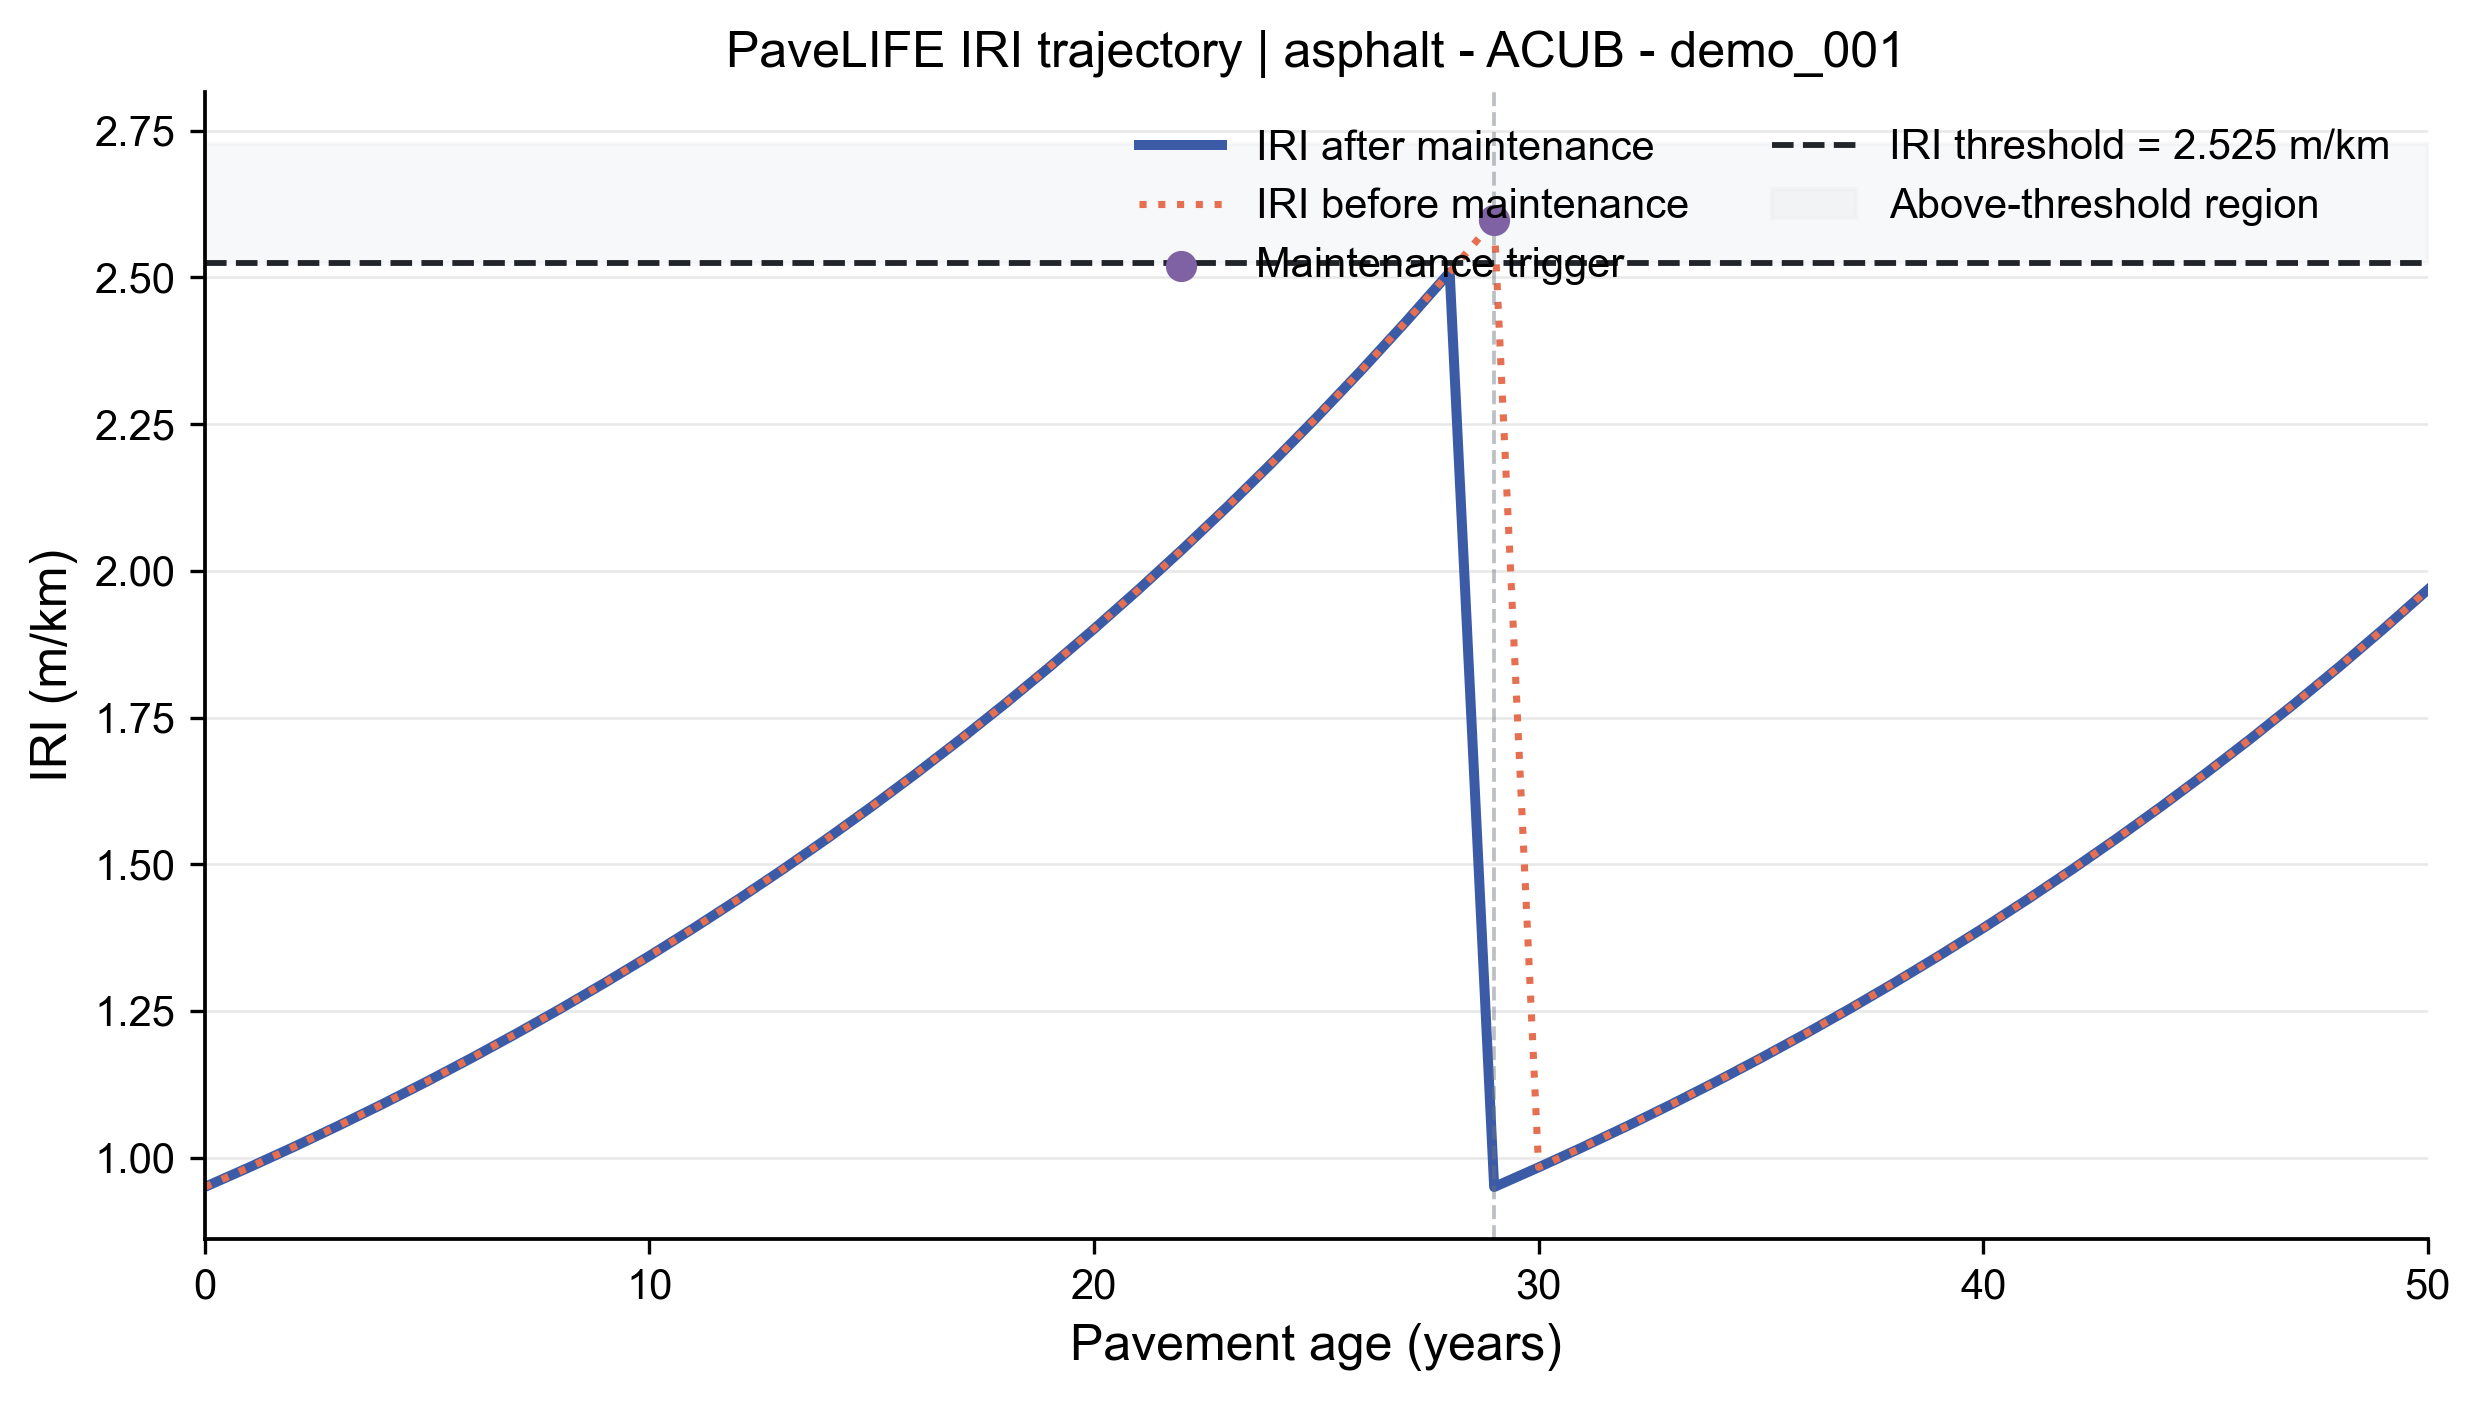

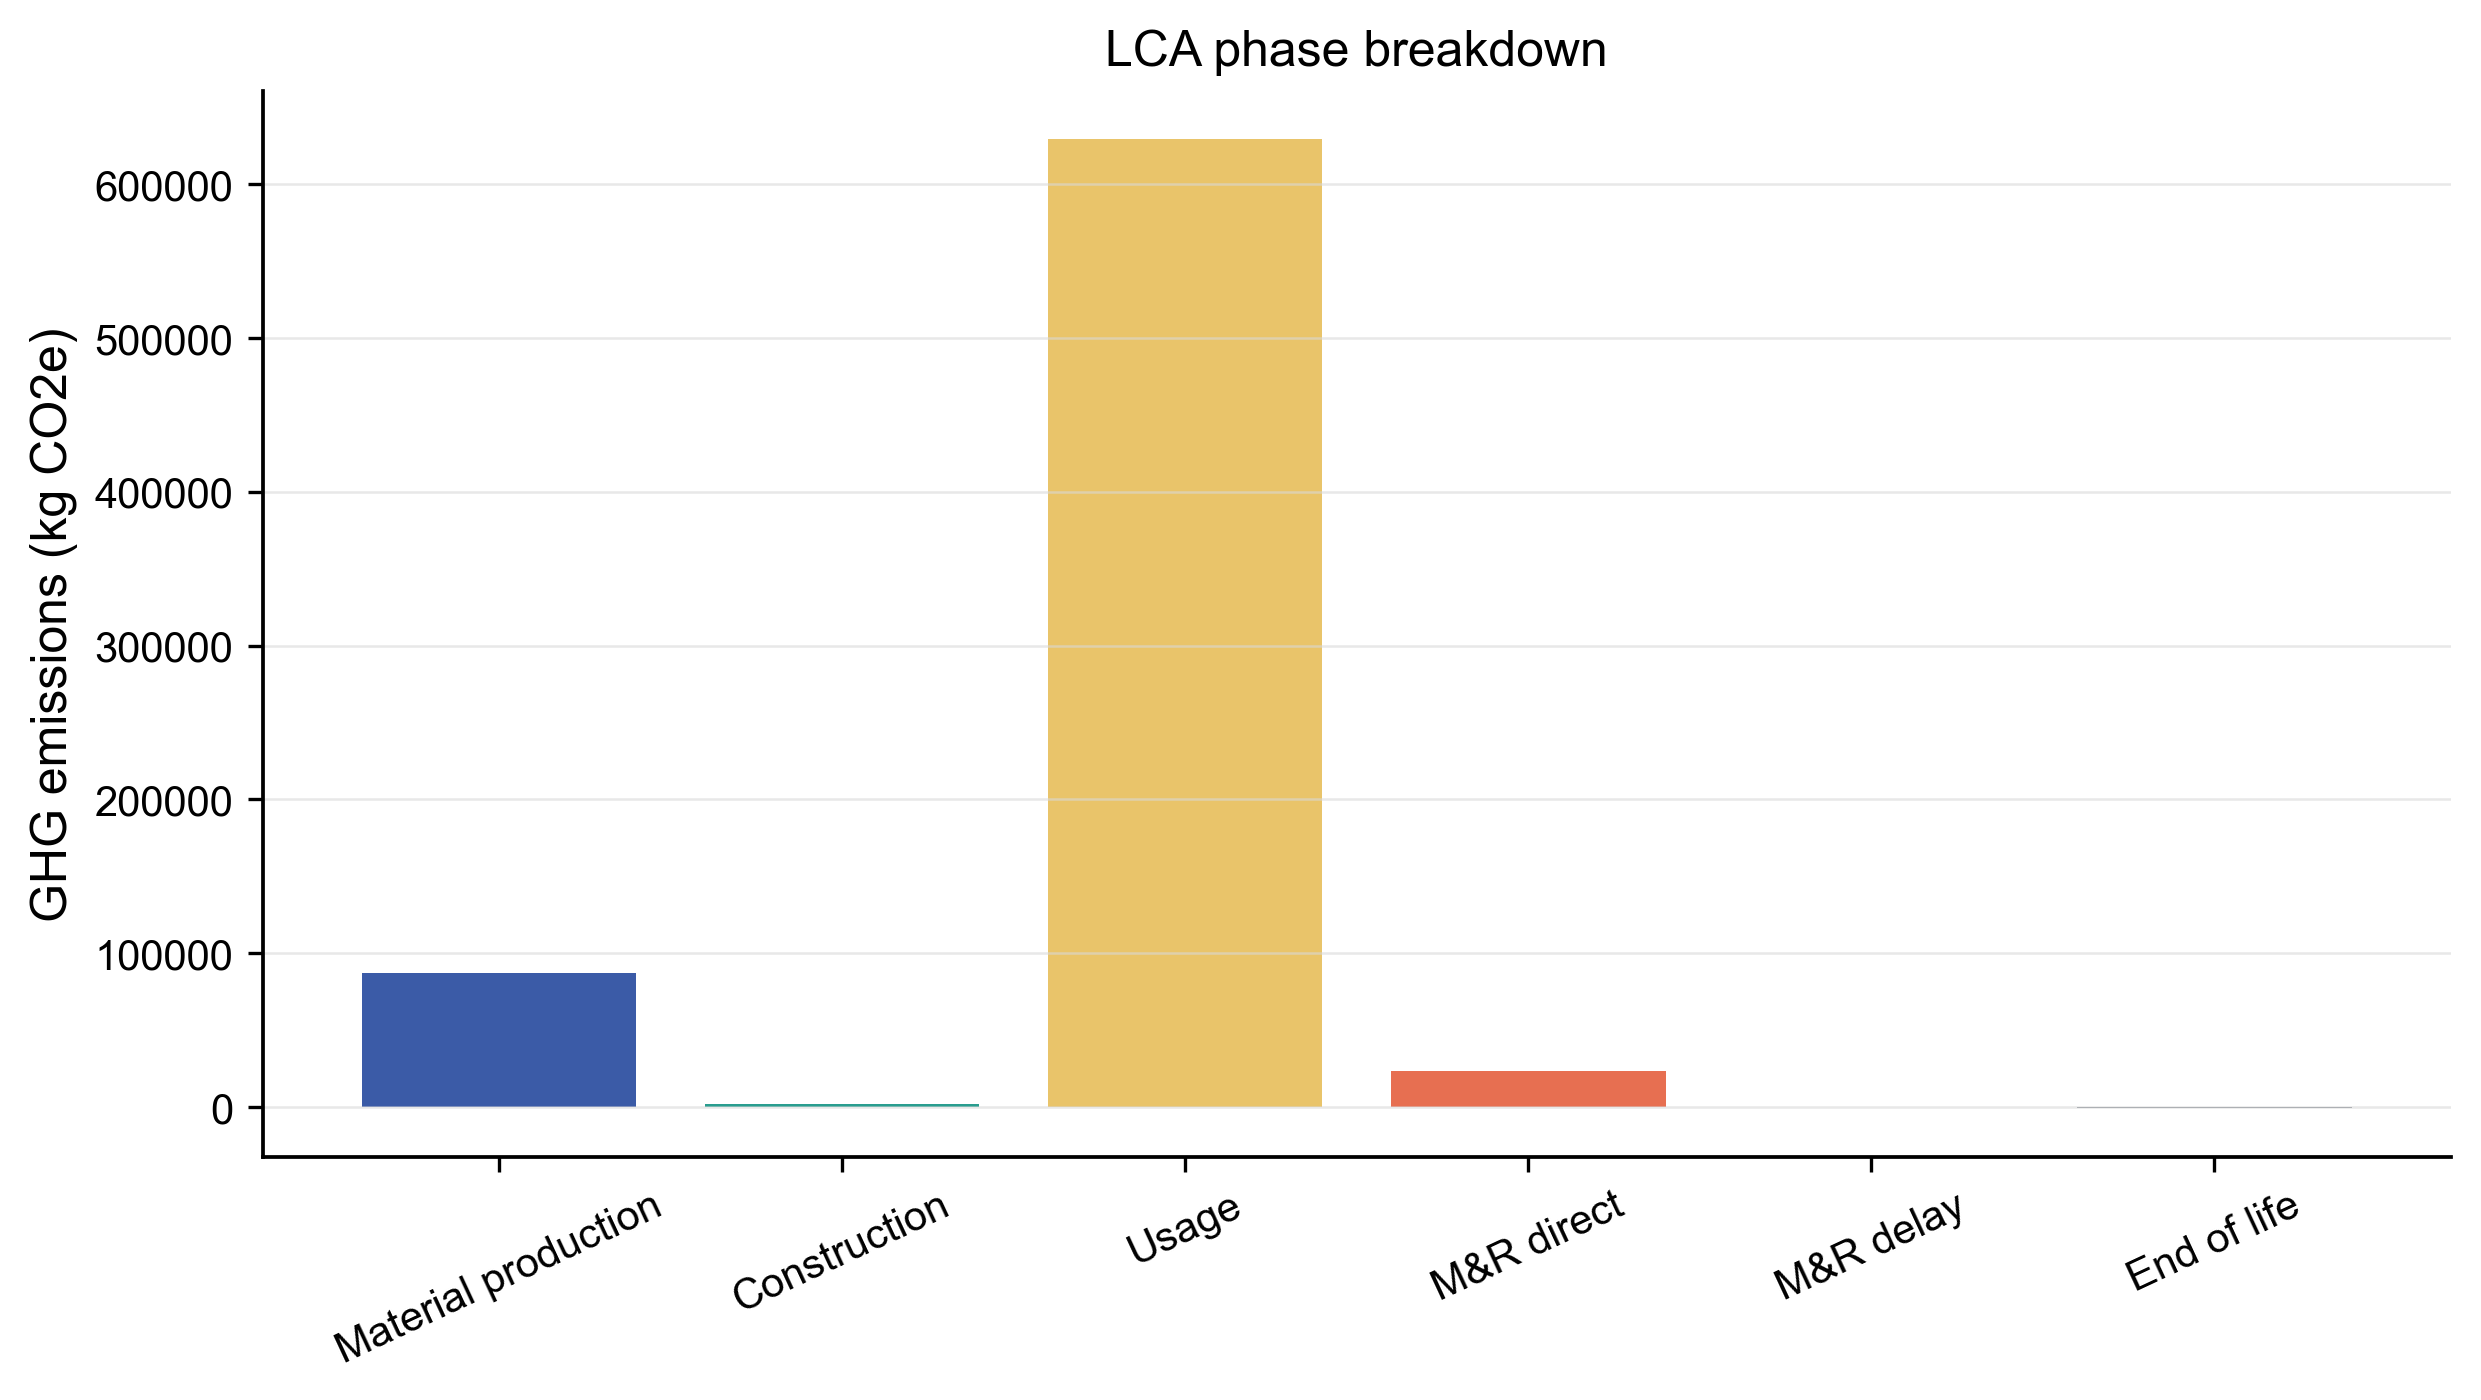

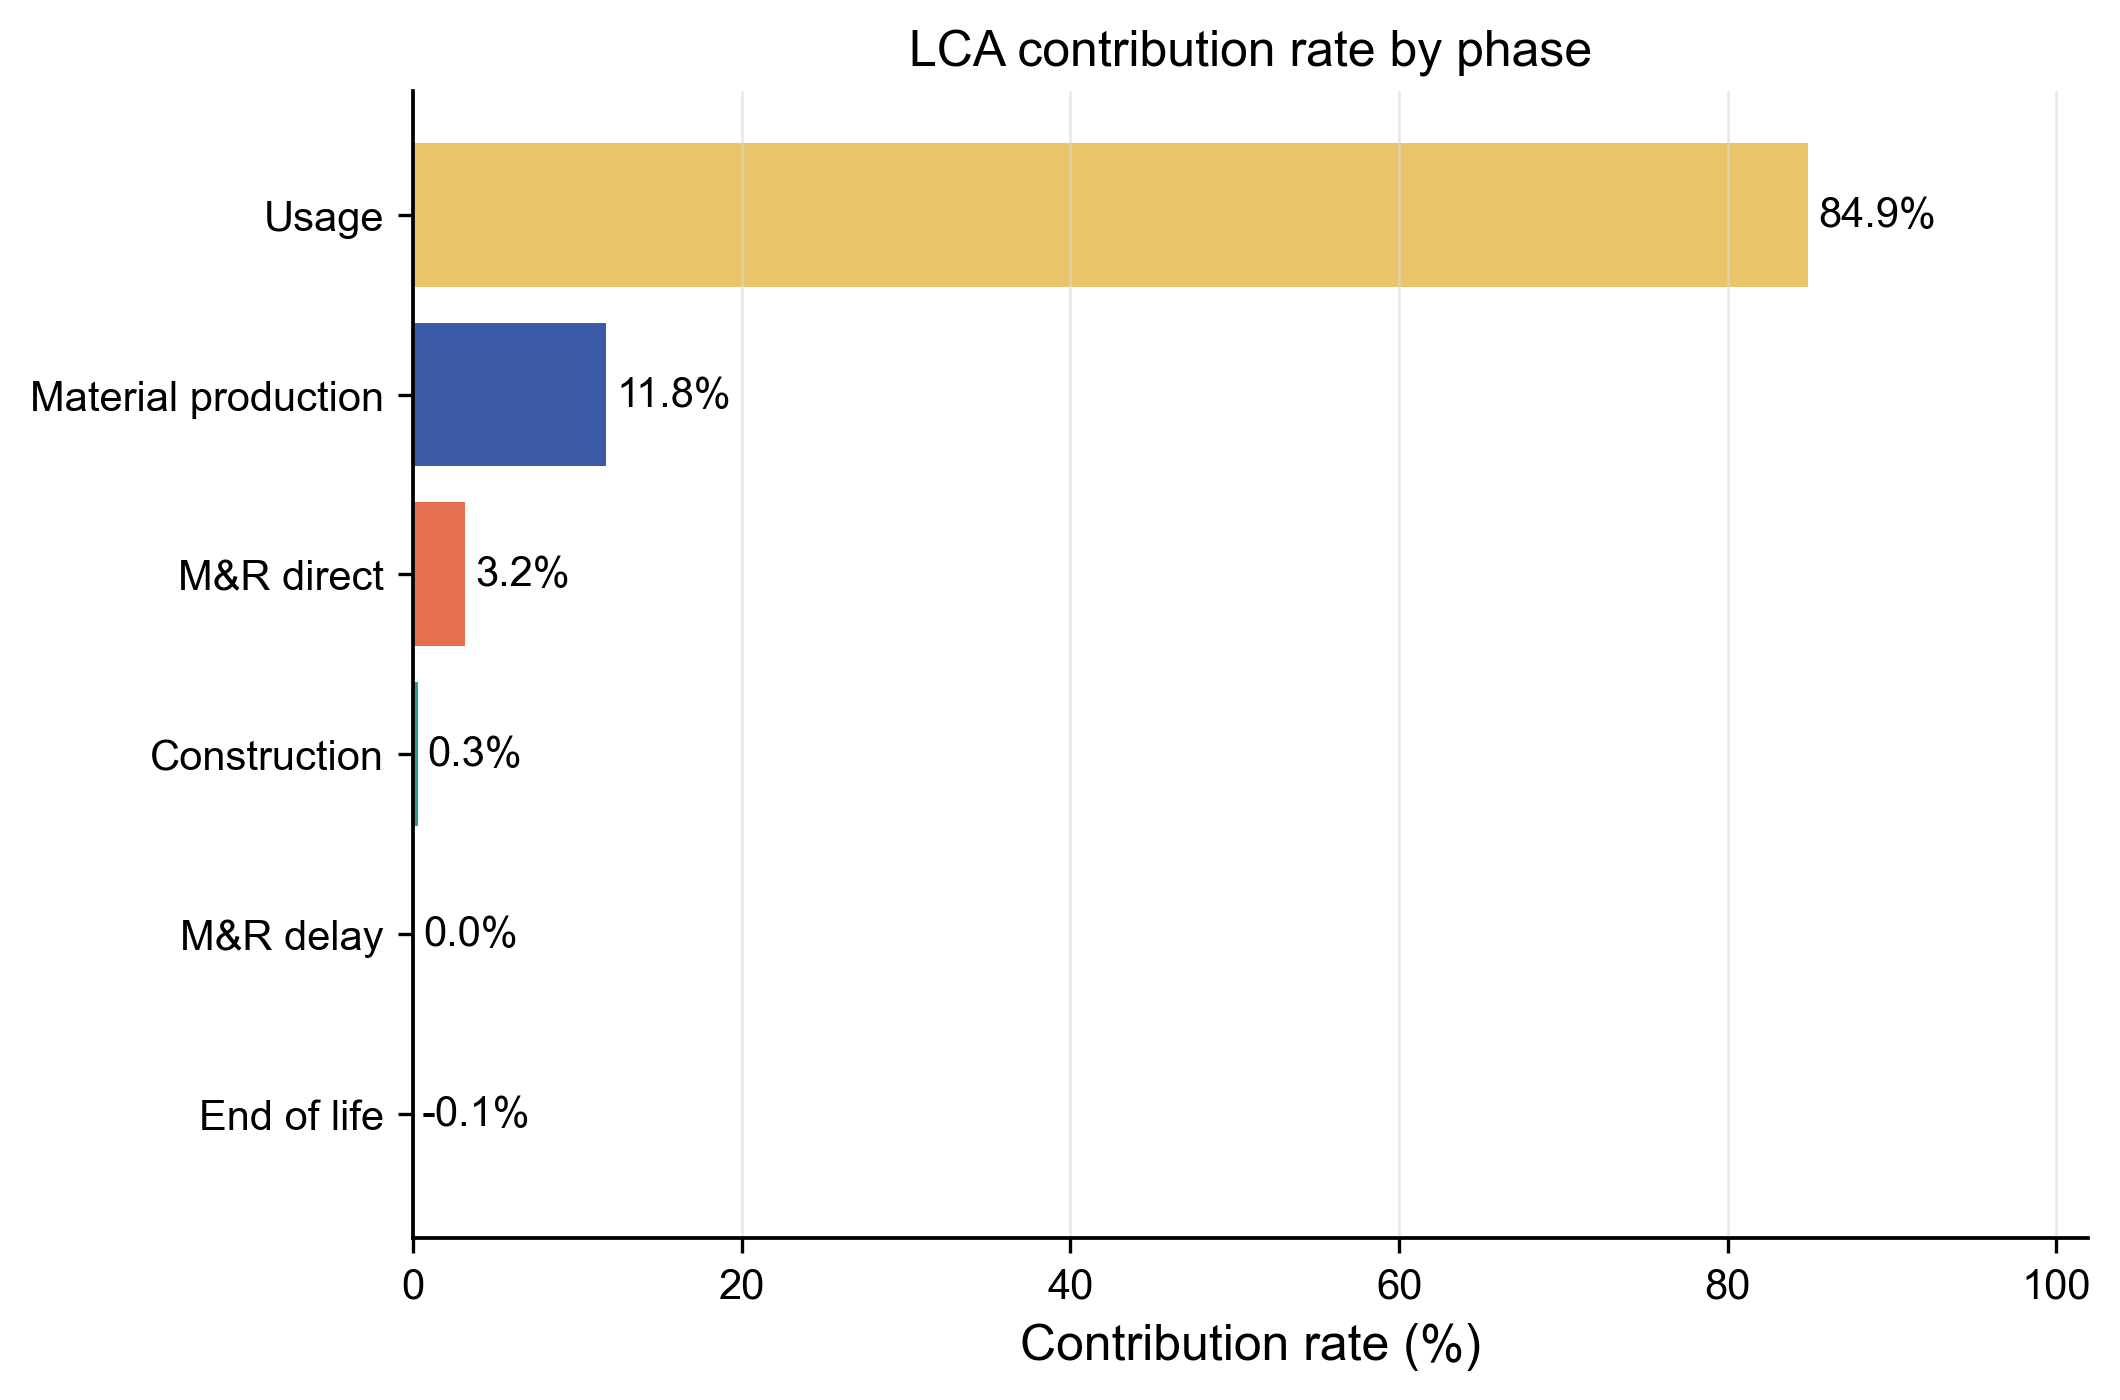

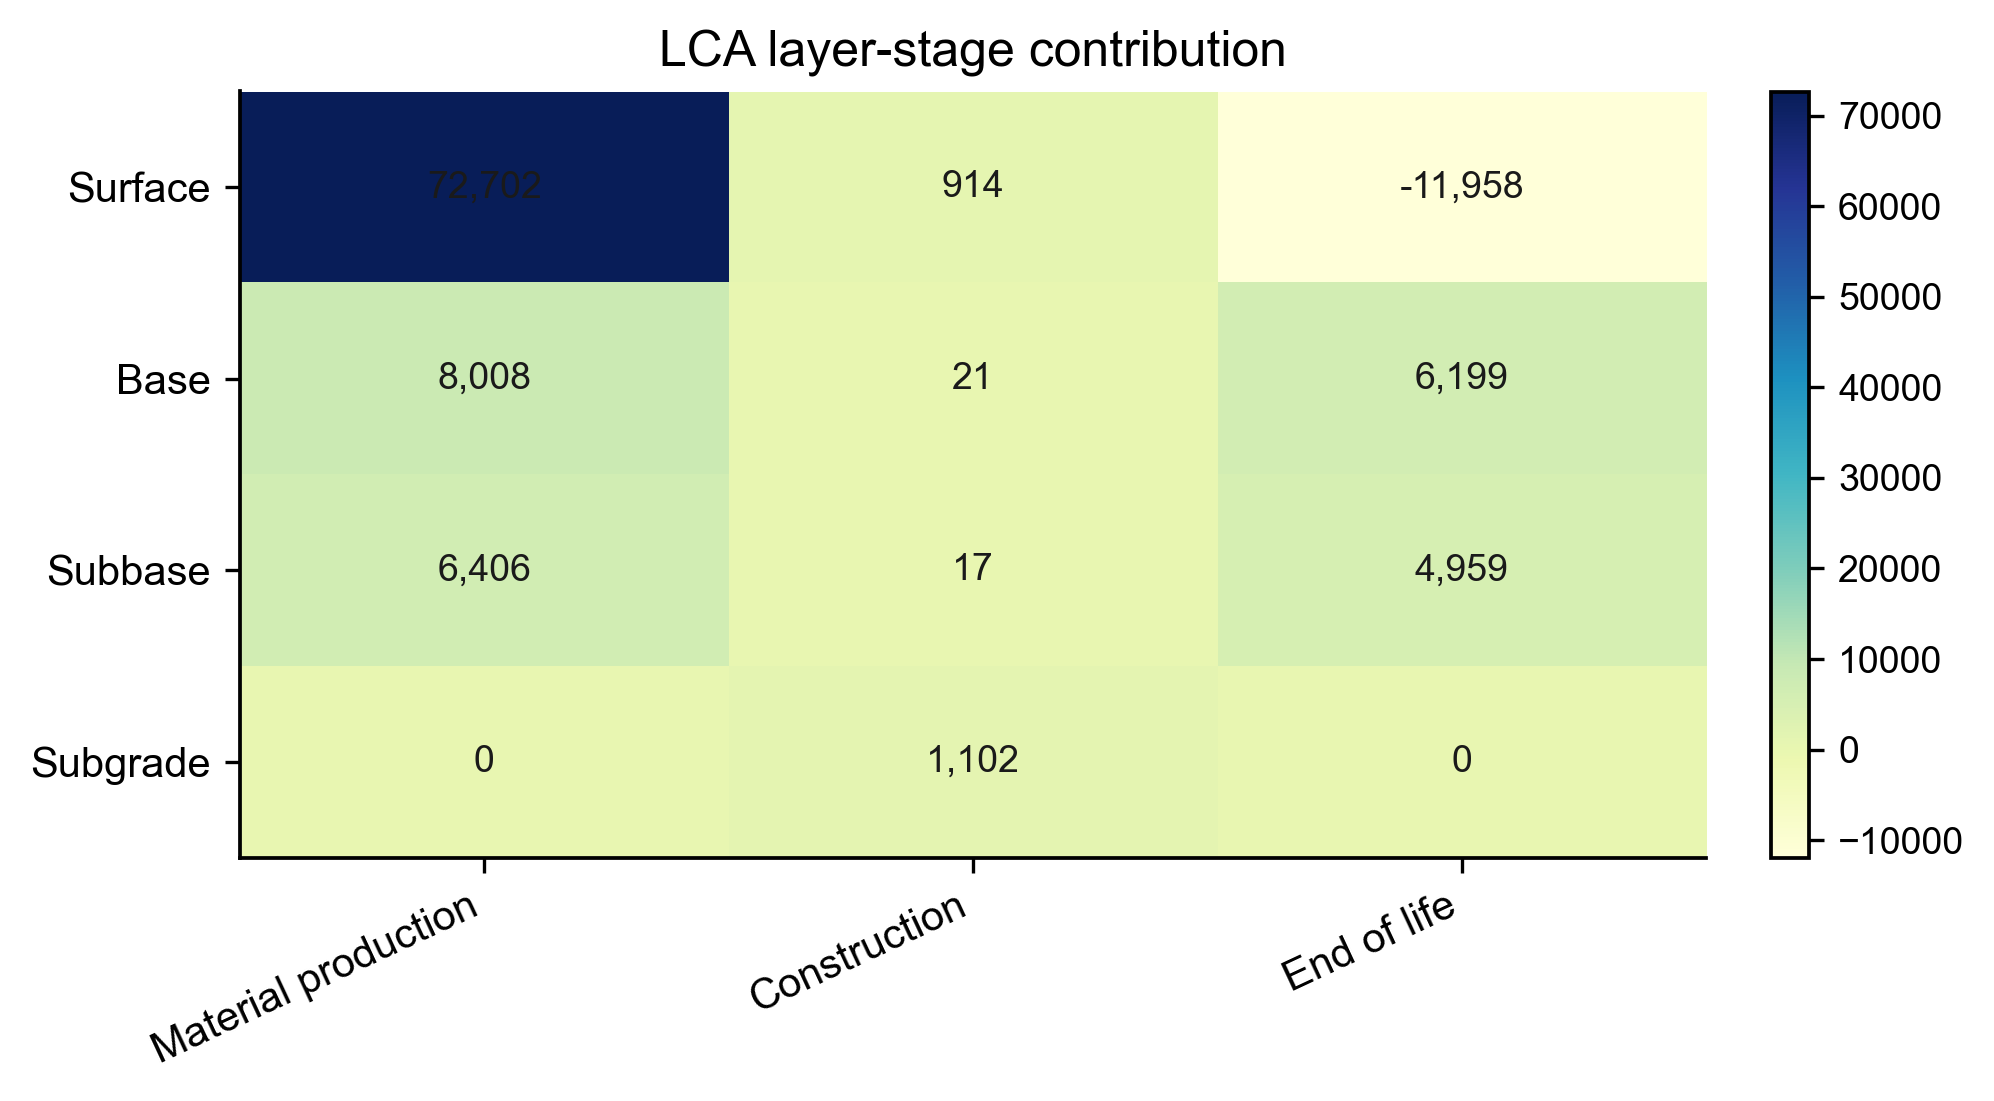

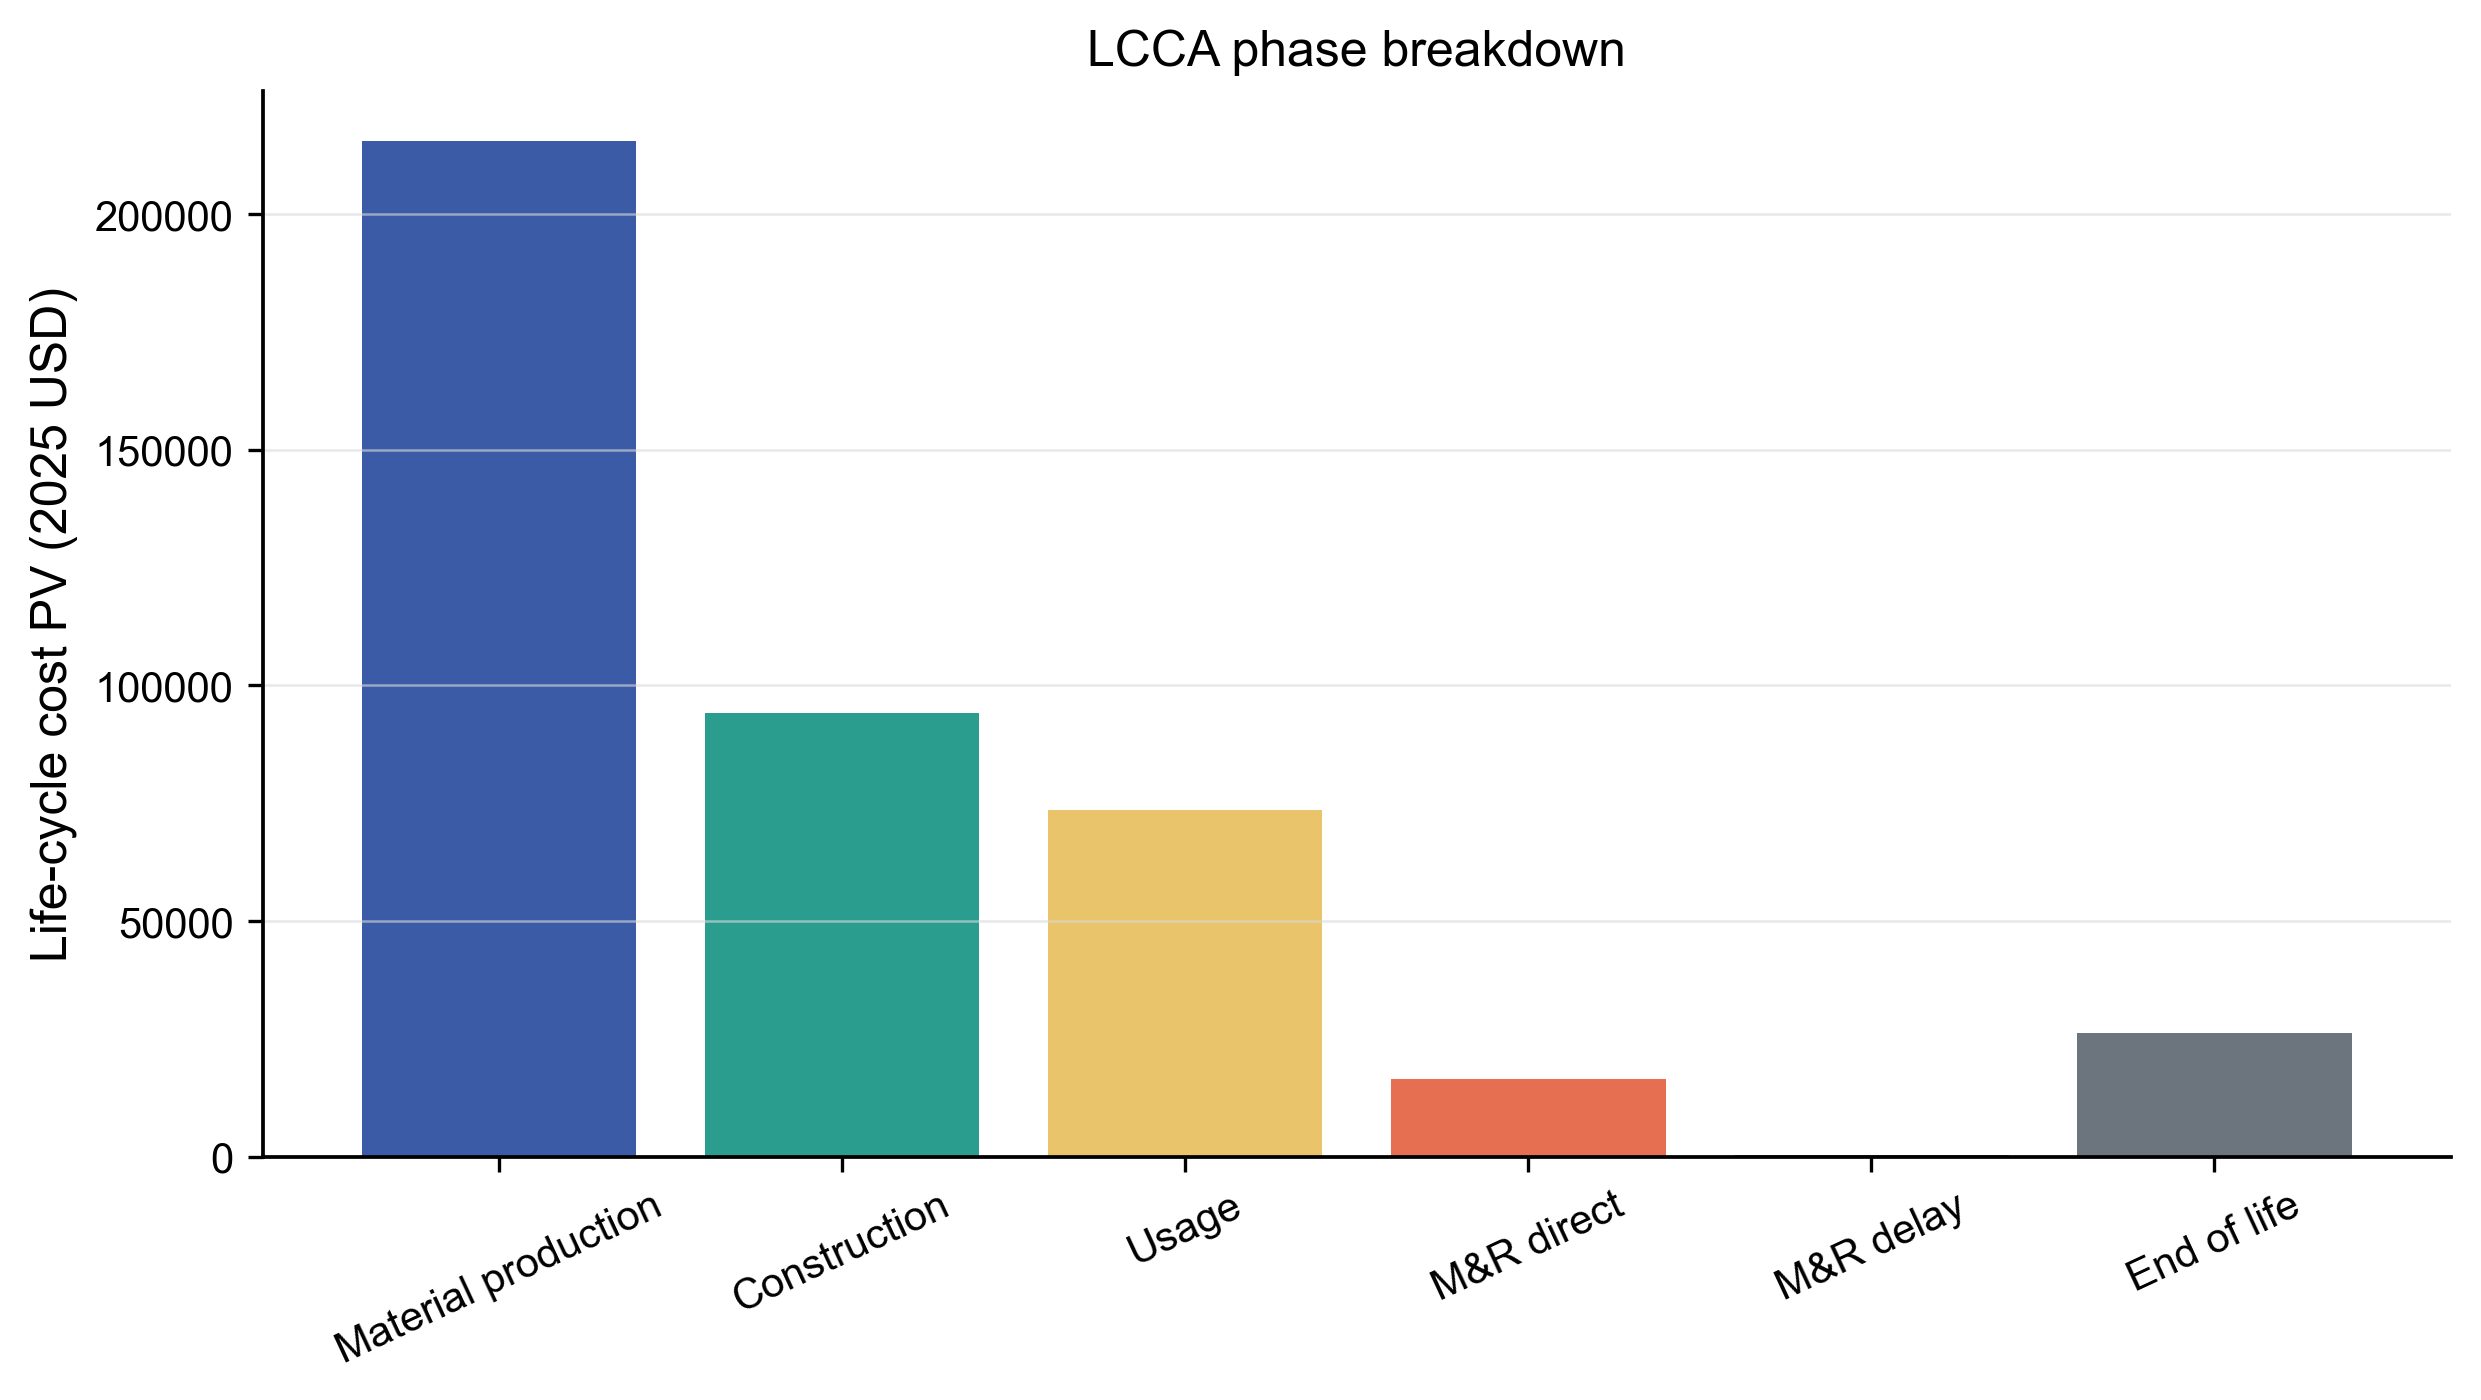

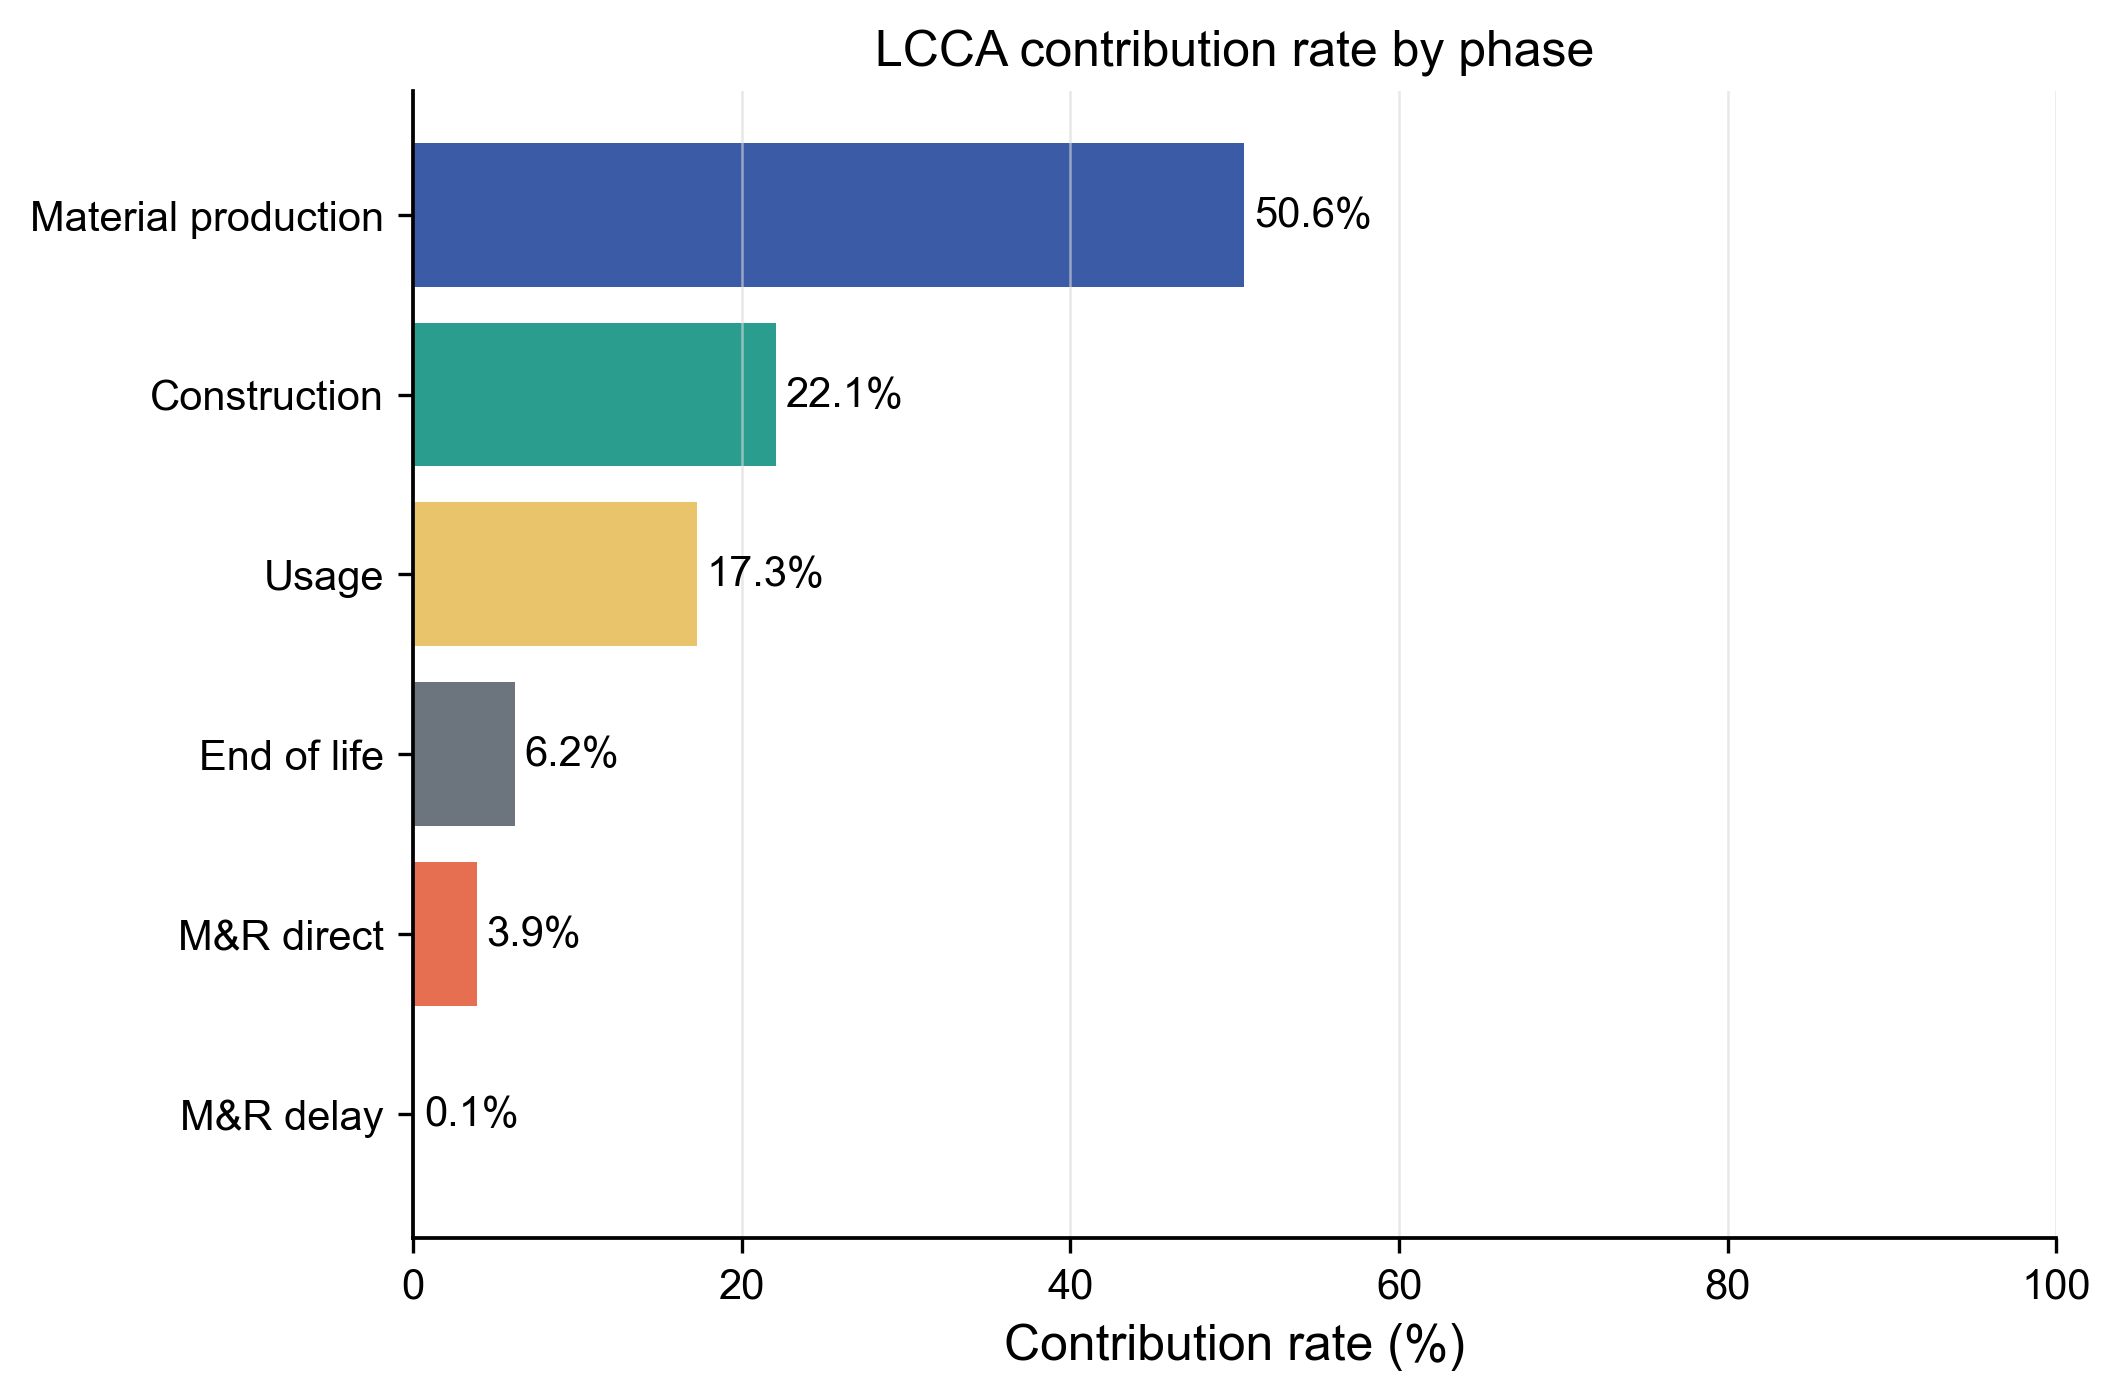

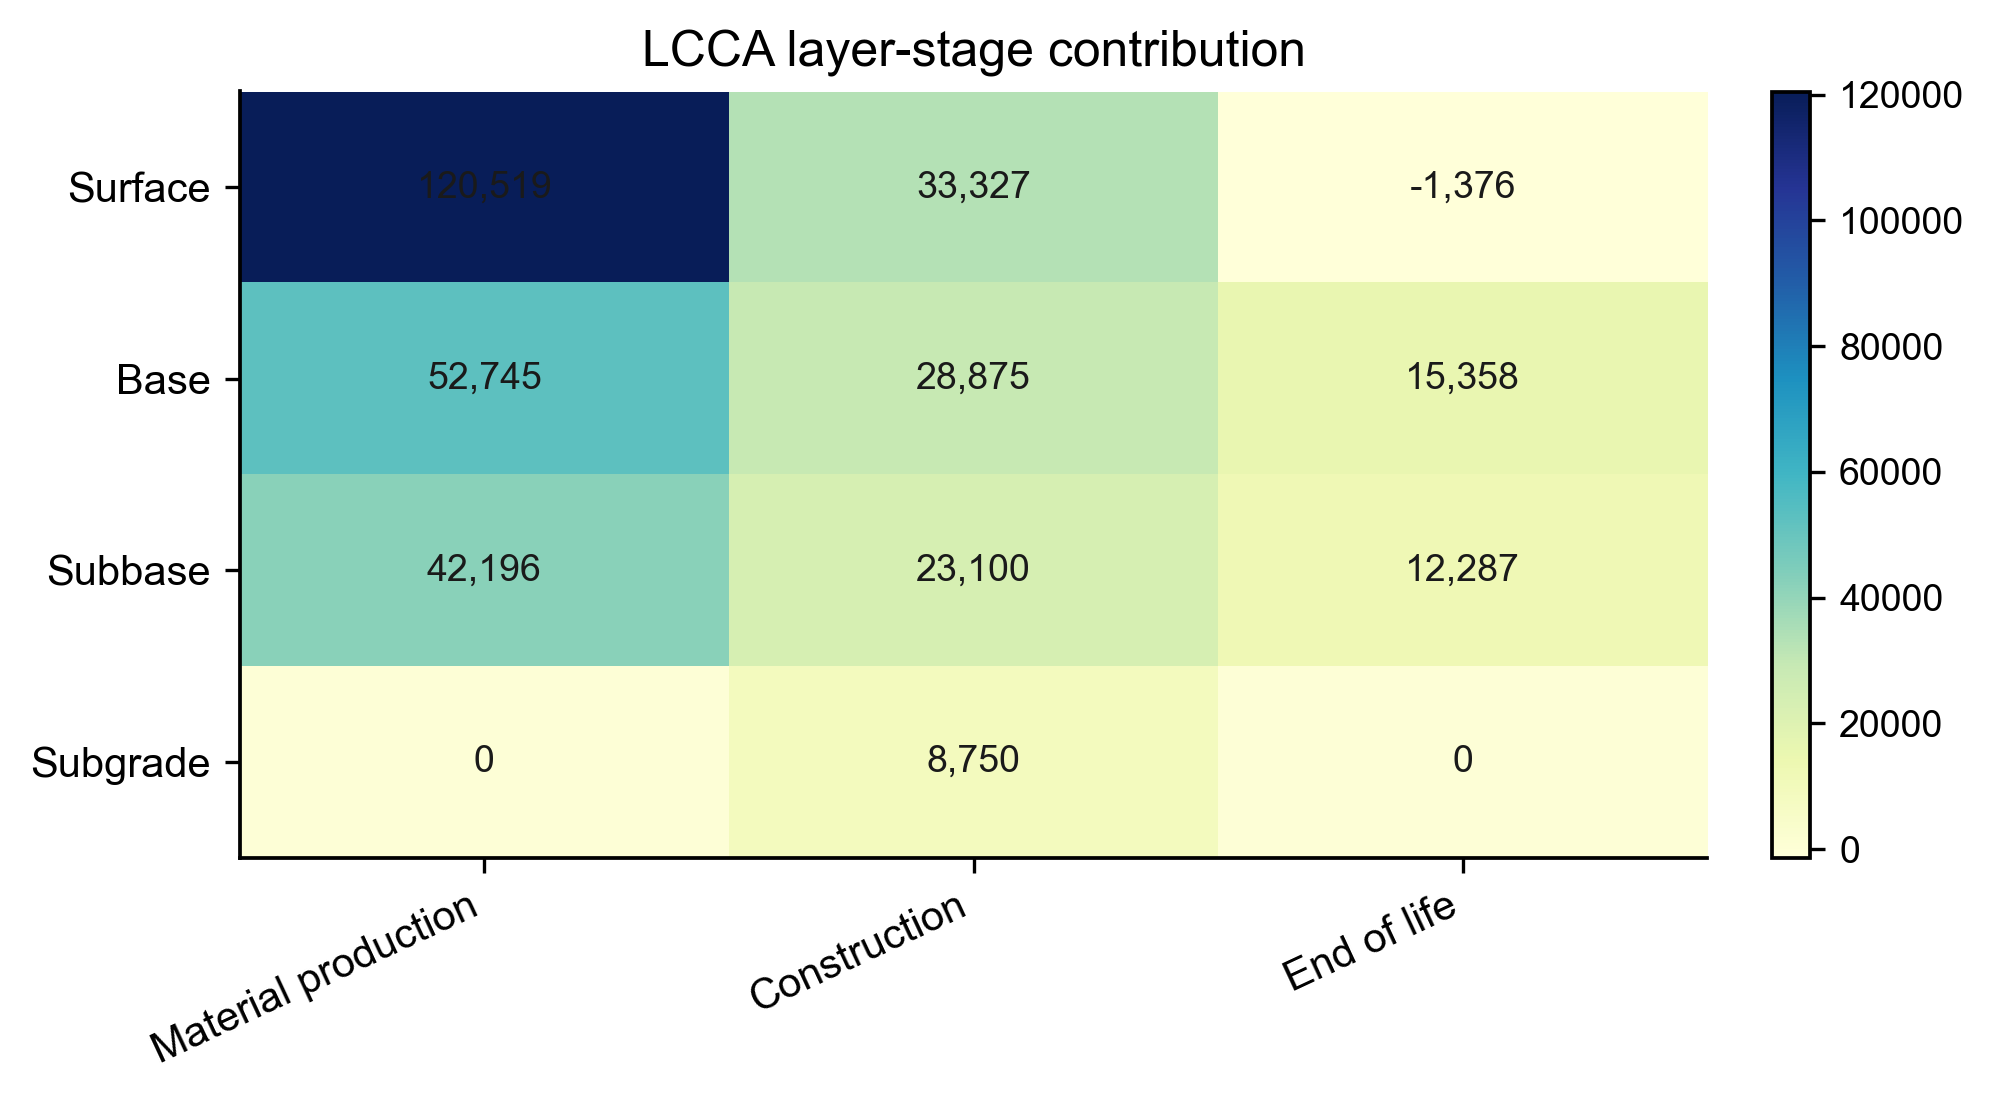

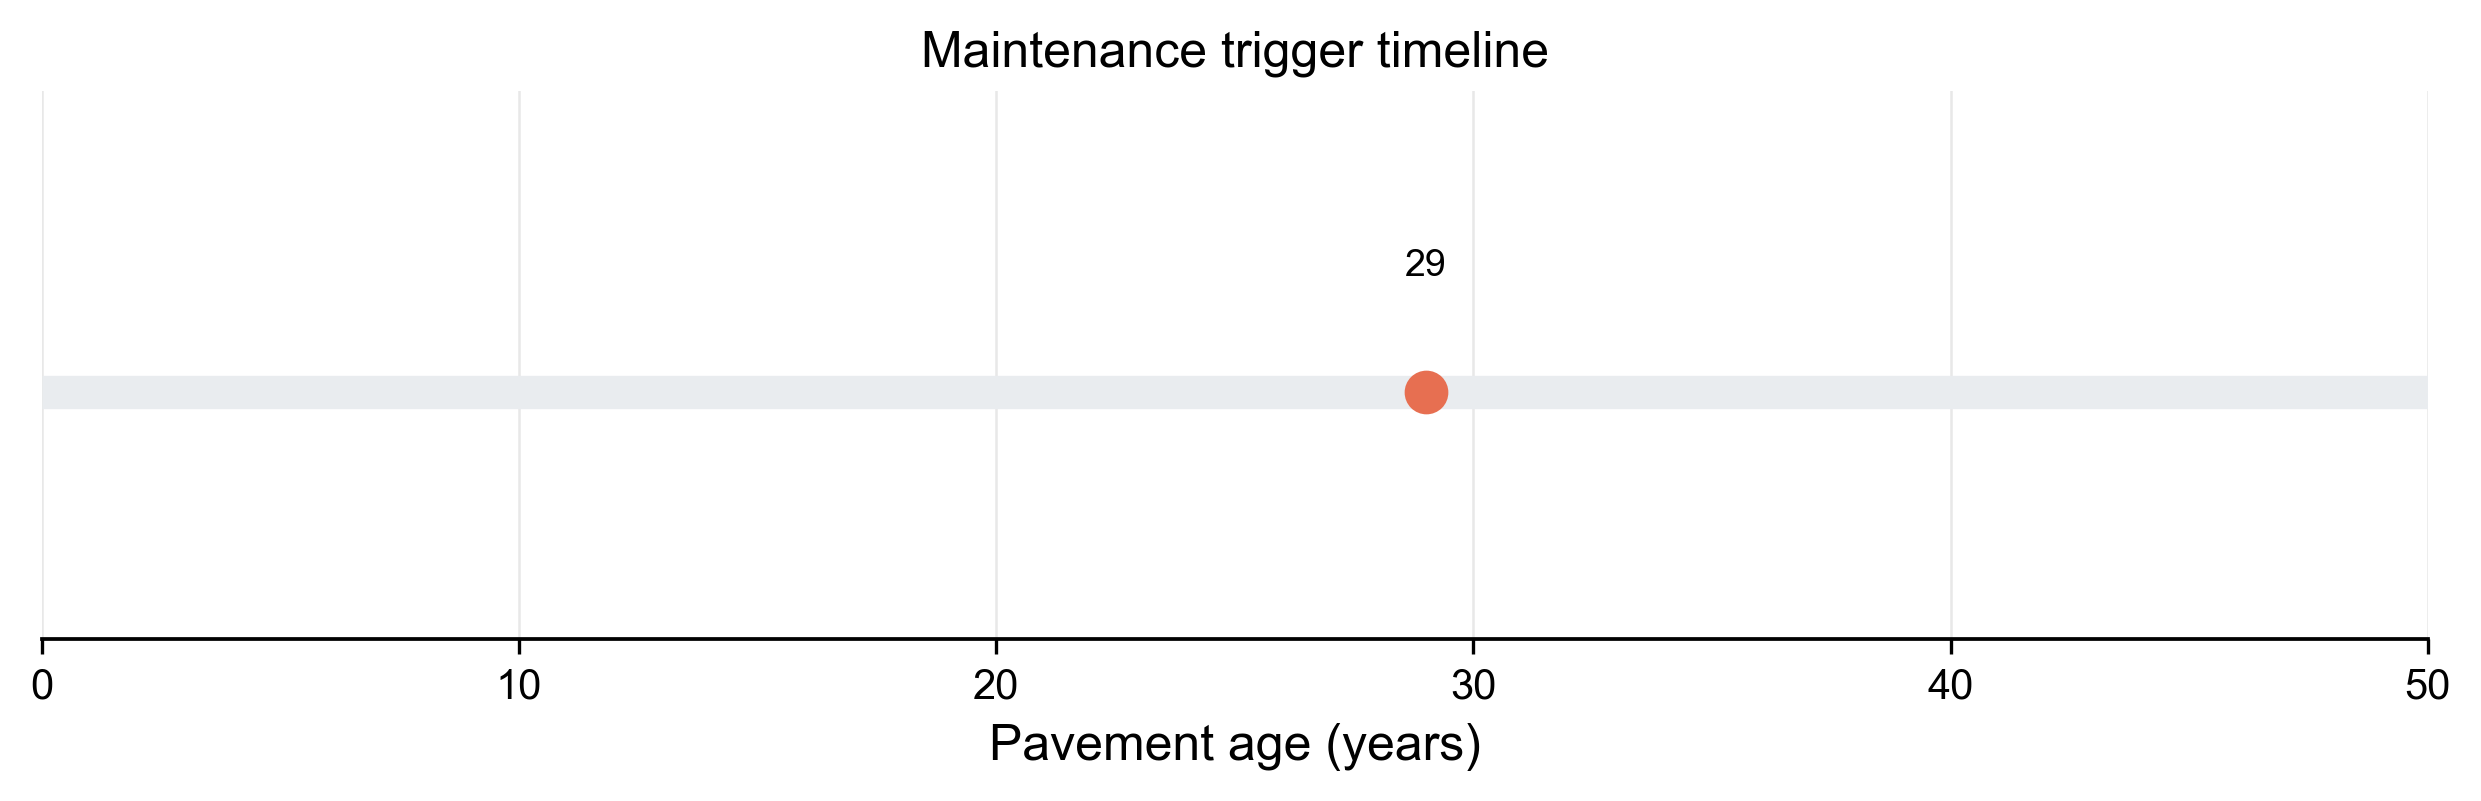

PaveLIFE unified single-section LCA-LCCA calculation completed.
Pavement family: asphalt
Pavement type: ACUB
SHRP_ID: demo_001
rate_log_pred: -1.459939
rate_pred: 0.03467857
Maintenance years: 29
Combined output workbook: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE/pavelife_unified_single_section\PaveLIFE_LCA_LCCA_asphalt_ACUB_demo_001_single_section.xlsx
IRI workbook: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE/pavelife_unified_single_section\life_cycle_iri\PaveLIFE_IRI_asphalt_ACUB_demo_001_single_section.xlsx
Figure paths:
  iri_progression: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE/pavelife_unified_single_section\figures\PaveLIFE_IRI_progression_asphalt_ACUB_demo_001.png
  lca_absolute: C:/Users/DELL/OneDrive/Papers/Research article XXX Evolving fleets & Diverse structures/PaveLIFE/pavelife_unified_single_section\figures\Pa

,SHRP_ID,Pavement family,Pavement type,IRI0,Precipitation,Temperature,Freeze index,AADT,AADTT,KESAL,Surface thickness,Base thickness,Subbase thickness,FUNC_CLASS,Asphalt thickness,rate_log_pred,rate_pred
0,demo_001,asphalt,ACUB,0.95,800.0,15.0,100.0,8000.0,800.0,500.0,6.0,10.0,8.0,1,6.0,-1.459939,0.034679


,SHRP_ID,Pavement family,Pavement type,FUNC_CLASS,FUNC_CLASS_EXP,IRI_threshold,car_speed_limit_kph,truck_speed_limit_kph,initial_IRI0,rate_log_pred,rate_pred,maintenance_count,maintenance_years
0,demo_001,asphalt,ACUB,1,Interstate/Freeways (Urban),2.525,88.5,80.5,0.95,-1.459939,0.034679,1,29


,SHRP_ID,Pavement family,Pavement type,Material Production,Material Production Surface,Material Production Base,Material Production Subbase,Construction,Construction Surface,Construction Base,Construction Subbase,Construction Subgrade,Usage,Maintenance Direct,Maintenance Traffic Delay,Maintenance Total,EOL,EOL Surface,EOL Base,EOL Subbase,Total Emission,Maintenance Count,Maintenance Years,Surface thickness (m),Base thickness (m),Subbase thickness (m),Surface mass (ton),Base mass (ton),Subbase mass (ton),Rebar mass (ton)
0,demo_001,asphalt,ACUB,87116.4,72702.0,8008.0,6406.4,2054.325,914.025,21.0,16.8,1102.5,629556.706688,23404.675,60.115101,23464.790101,-800.26275,-11957.736,6198.59625,4958.877,741391.959039,1,29,0.15,0.25,0.2,1260.0,1925.0,1540.0,0.0


,Phase,Phase label,Value,Unit,Contribution rate (%)
0,Material Production,Material production,87116.400000,kg CO2e,11.750384
1,Construction,Construction,2054.325000,kg CO2e,0.277090
2,Usage,Usage,629556.706688,kg CO2e,84.915502
3,Maintenance Direct,M&R direct,23404.675000,kg CO2e,3.156856
4,Maintenance Traffic Delay,M&R delay,60.115101,kg CO2e,0.008108
5,EOL,End of life,-800.262750,kg CO2e,-0.107941


,SHRP_ID,Pavement family,Pavement type,Material Production,Material Production Surface,Material Production Base,Material Production Subbase,Construction,Construction Surface,Construction Base,Construction Subbase,Construction Subgrade,Usage,Usage Undiscounted,Maintenance Direct,Maintenance Direct Undiscounted,Maintenance Traffic Delay,Maintenance Traffic Delay Undiscounted,Maintenance Total,Maintenance Total Undiscounted,EOL,EOL Undiscounted,EOL Surface,EOL Base,EOL Subbase,Total Cost,Total Cost Undiscounted,Maintenance Count,Maintenance Years,Surface thickness (m),Base thickness (m),Subbase thickness (m),Surface mass (ton),Base mass (ton),Subbase mass (ton),Rebar mass (ton)
0,demo_001,asphalt,ACUB,215460.0,120519.0,52745.0,42196.0,94052.0,33327.0,28875.0,23100.0,8750.0,73577.283453,221705.380398,16443.645848,51282.0,311.641502,971.901221,16755.28735,52253.901221,26269.34266,186687.9,-1375.831668,15358.430182,12286.744146,426113.913462,770159.181619,1,29,0.15,0.25,0.2,1260.0,1925.0,1540.0,0.0


,Phase,Phase label,Value,Unit,Contribution rate (%)
0,Material Production,Material production,215460.000000,2025 USD PV,50.563944
1,Construction,Construction,94052.000000,2025 USD PV,22.072032
2,Usage,Usage,73577.283453,2025 USD PV,17.267046
3,Maintenance Direct,M&R direct,16443.645848,2025 USD PV,3.858979
4,Maintenance Traffic Delay,M&R delay,311.641502,2025 USD PV,0.073136
5,EOL,End of life,26269.342660,2025 USD PV,6.164864


In [22]:

# ============================================================
# 10. Run PaveLIFE for the current section_input
# ============================================================
# Modify section_input in Cell 0, then run this cell.
results = run_pavelife_single_section(section_input)

# Preview key outputs.
display(results["rate_prediction"])
display(results["maintenance_summary"])
display(results["lca_summary"])
display(results["lca_phase_contribution"])
display(results["lcca_summary"])
display(results["lcca_phase_contribution"])
